# Synthetic Landmark Shape-Space Analysis

This notebook analyzes the synthetic 72-landmark dataset used to train the landmark model.

Expected dataset structure:

```text
root/
  train/
    images/
    labels/
  val/
    images/
    labels/
  test/
    images/
    labels/
```

Each label file is expected to follow the new format:

```text
class_idx
x1 y1 v1
...
x72 y72 v72
```

Class mapping:

```text
0 = left
1 = quarter_left
2 = frontal
3 = quarter_right
4 = right
```

Main goals:

1. Validate the dataset and label format.
2. Inspect orientation and visibility distributions.
3. Analyze mean shapes and landmark variability.
4. Compare global PCA vs class-conditioned PCA.
5. Compare PCA with and without Procrustes alignment.
6. Examine PCA score normality.
7. Analyze pairwise class separation.
8. Identify outlier samples by reconstruction error.

The notebook is exploratory and does not modify the dataset.

## How to run

1. Set `DATASET_ROOT` to the root of your synthetic dataset.
2. Set `OUTPUT_ROOT` to a folder where tables and figures should be saved.
3. Run all cells from top to bottom.
4. Start with `SPLIT_FOR_ANALYSIS = "train"`, because PCA fitting must be based only on the train split.
5. Inspect the generated tables and figures under `OUTPUT_ROOT`.

Recommended first run:

```python
DATASET_ROOT = Path("/path/to/synthetic_dataset")
OUTPUT_ROOT = Path("/path/to/shape_analysis_outputs")
SPLIT_FOR_ANALYSIS = "train"
```

Important: PCA fitting must use only the train split. Validation and test can be loaded later for descriptive checks, but they should not be used to fit PCA priors.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False
    stats = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [2]:
# =============================
# Configuration
# =============================

DATASET_ROOT = Path("/Users/jocareher/Documents/synthetic_lmks_vis_dataset")
OUTPUT_ROOT = Path("/Users/jocareher/Documents/synthetic_lmks_vis_dataset/shape_analysis_outputs")
SPLIT_FOR_ANALYSIS = "train"

NUM_LANDMARKS = 72
CLASS_NAMES = {
    0: "left",
    1: "quarter_left",
    2: "frontal",
    3: "quarter_right",
    4: "right",
}

MAX_COMPONENTS_TO_VISUALIZE = 6
COMPONENT_STD_MULTIPLIER = 2.0
EXPLAINED_VARIANCE_THRESHOLD = 0.95
MAX_COMPONENTS_PER_PCA = 20

ALLOW_REFLECTION = False
PROCRUSTES_MAX_ITERATIONS = 50
PROCRUSTES_TOLERANCE = 1e-7

TABLES_DIR = OUTPUT_ROOT / "tables"
FIGURES_DIR = OUTPUT_ROOT / "figures"
OUTLIERS_DIR = OUTPUT_ROOT / "outliers"

for directory in [OUTPUT_ROOT, TABLES_DIR, FIGURES_DIR, OUTLIERS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Dataset root: {DATASET_ROOT.resolve()}")
print(f"Output root : {OUTPUT_ROOT.resolve()}")


Dataset root: /Users/jocareher/Documents/synthetic_lmks_vis_dataset
Output root : /Users/jocareher/Documents/synthetic_lmks_vis_dataset/shape_analysis_outputs


## Landmark groups

The analysis uses anatomical groups to aggregate landmark variability and reconstruction errors. Adjust the last four landmark groups if their anatomical meaning differs in your annotation schema.

In [3]:
def get_anatomical_group(landmark_idx: int) -> str:
    """
    Return the anatomical group for a landmark index.

    Args:
        landmark_idx: Zero-based landmark index.

    Returns:
        The anatomical group name.
    """
    if 0 <= landmark_idx <= 16:
        return "face_contour"
    if 17 <= landmark_idx <= 21:
        return "right_eyebrow"
    if 22 <= landmark_idx <= 26:
        return "left_eyebrow"
    if 27 <= landmark_idx <= 30:
        return "nose_bridge"
    if 31 <= landmark_idx <= 35:
        return "nose_base"
    if 36 <= landmark_idx <= 41:
        return "right_eye"
    if 42 <= landmark_idx <= 47:
        return "left_eye"
    if 48 <= landmark_idx <= 59:
        return "outer_lip"
    if 60 <= landmark_idx <= 67:
        return "inner_lip"
    if 68 <= landmark_idx <= 69:
        return "upper_chin"
    if 70 <= landmark_idx <= 71:
        return "lower_chin"
    return "unknown"


def get_anatomical_label(landmark_idx: int) -> str:
    """
    Return a human-readable anatomical label with one-based landmark index.

    Args:
        landmark_idx: Zero-based landmark index.

    Returns:
        A label in the format '<group>_<one_based_index>'.
    """
    return f"{get_anatomical_group(landmark_idx)}_{landmark_idx + 1}"


LANDMARK_GROUP_TABLE = pd.DataFrame(
    {
        "landmark_idx": list(range(NUM_LANDMARKS)),
        "landmark_number": list(range(1, NUM_LANDMARKS + 1)),
        "anatomical_group": [get_anatomical_group(i) for i in range(NUM_LANDMARKS)],
        "anatomical_label": [get_anatomical_label(i) for i in range(NUM_LANDMARKS)],
    }
)
LANDMARK_GROUP_TABLE.to_csv(TABLES_DIR / "landmark_group_mapping.csv", index=False)
LANDMARK_GROUP_TABLE.head(10)


,landmark_idx,landmark_number,anatomical_group,anatomical_label
0,0,1,face_contour,face_contour_1
1,1,2,face_contour,face_contour_2
2,2,3,face_contour,face_contour_3
3,3,4,face_contour,face_contour_4
4,4,5,face_contour,face_contour_5
5,5,6,face_contour,face_contour_6
6,6,7,face_contour,face_contour_7
7,7,8,face_contour,face_contour_8
8,8,9,face_contour,face_contour_9
9,9,10,face_contour,face_contour_10


## Data loading

The parser reads the new label format and returns landmarks, visibility, class index, and metadata. It intentionally does not modify any file.

In [4]:
@dataclass
class LandmarkSample:
    """
    Container for one landmark sample.

    Attributes:
        split: Dataset split name.
        label_path: Path to the label file.
        image_path: Optional path to the corresponding image.
        stem: File stem shared by image and label.
        class_idx: Orientation class index.
        class_name: Orientation class name.
        landmarks: Landmark coordinates with shape [N, 2].
        visibility: Visibility flags with shape [N].
    """
    split: str
    label_path: Path
    image_path: Optional[Path]
    stem: str
    class_idx: int
    class_name: str
    landmarks: np.ndarray
    visibility: np.ndarray


def find_matching_image(images_dir: Path, stem: str) -> Optional[Path]:
    """
    Find an image file matching a given stem.

    Args:
        images_dir: Directory containing images.
        stem: File stem to search for.

    Returns:
        The matching image path, or None if not found.
    """
    for suffix in [".jpg", ".jpeg", ".png", ".bmp"]:
        candidate = images_dir / f"{stem}{suffix}"
        if candidate.exists():
            return candidate
    return None


def parse_landmark_label(label_path: Path, num_landmarks: int = NUM_LANDMARKS) -> Tuple[int, np.ndarray, np.ndarray]:
    """
    Parse a landmark label file with class_idx header.

    Args:
        label_path: Path to the label file.
        num_landmarks: Expected number of landmarks.

    Returns:
        A tuple with class_idx, landmarks [N, 2], and visibility [N].
    """
    with open(label_path, "r", encoding="utf-8") as file:
        lines = [line.strip() for line in file if line.strip()]

    if len(lines) < num_landmarks + 1:
        raise ValueError(f"Expected at least {num_landmarks + 1} non-empty lines in {label_path}, got {len(lines)}.")

    first_parts = lines[0].split()
    if len(first_parts) != 1:
        raise ValueError(f"First line must contain only class_idx in {label_path}.")

    class_idx = int(first_parts[0])
    if class_idx not in CLASS_NAMES:
        raise ValueError(f"class_idx must be in {sorted(CLASS_NAMES)}, got {class_idx} in {label_path}.")

    landmark_rows = []
    visibility_values = []
    for line_idx, line in enumerate(lines[1 : num_landmarks + 1], start=2):
        parts = line.split()
        if len(parts) != 3:
            raise ValueError(f"Expected landmark row with 3 values at line {line_idx} in {label_path}, got: {line}")
        x_value, y_value, visibility_value = map(float, parts)
        landmark_rows.append([x_value, y_value])
        visibility_values.append(int(round(visibility_value)))

    landmarks = np.asarray(landmark_rows, dtype=np.float64)
    visibility = np.asarray(visibility_values, dtype=np.int64)
    return class_idx, landmarks, visibility


def load_split_samples(dataset_root: Path, split: str, num_landmarks: int = NUM_LANDMARKS) -> List[LandmarkSample]:
    """
    Load all landmark samples from one split.

    Args:
        dataset_root: Dataset root directory.
        split: Split name, for example 'train'.
        num_landmarks: Expected number of landmarks.

    Returns:
        A list of LandmarkSample instances.
    """
    labels_dir = dataset_root / split / "labels"
    images_dir = dataset_root / split / "images"

    if not labels_dir.exists():
        raise FileNotFoundError(f"Labels directory not found: {labels_dir}")

    samples: List[LandmarkSample] = []
    errors: List[str] = []

    for label_path in sorted(labels_dir.glob("*.txt")):
        try:
            class_idx, landmarks, visibility = parse_landmark_label(label_path, num_landmarks=num_landmarks)
            stem = label_path.stem
            image_path = find_matching_image(images_dir, stem) if images_dir.exists() else None
            samples.append(
                LandmarkSample(
                    split=split,
                    label_path=label_path,
                    image_path=image_path,
                    stem=stem,
                    class_idx=class_idx,
                    class_name=CLASS_NAMES[class_idx],
                    landmarks=landmarks,
                    visibility=visibility,
                )
            )
        except Exception as error:
            errors.append(f"{label_path}: {error}")

    if errors:
        print(f"Found {len(errors)} parsing errors in split '{split}'. First 10 errors:")
        for error in errors[:10]:
            print(f"  {error}")

    return samples


def samples_to_arrays(samples: Sequence[LandmarkSample]) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[str]]:
    """
    Convert samples into stacked arrays.

    Args:
        samples: Sequence of LandmarkSample instances.

    Returns:
        Tuple with landmarks [M, N, 2], visibility [M, N], class_idx [M], and stems.
    """
    landmarks = np.stack([sample.landmarks for sample in samples], axis=0)
    visibility = np.stack([sample.visibility for sample in samples], axis=0)
    class_indices = np.asarray([sample.class_idx for sample in samples], dtype=np.int64)
    stems = [sample.stem for sample in samples]
    return landmarks, visibility, class_indices, stems


In [5]:
train_samples = load_split_samples(DATASET_ROOT, SPLIT_FOR_ANALYSIS, num_landmarks=NUM_LANDMARKS)
train_landmarks, train_visibility, train_class_indices, train_stems = samples_to_arrays(train_samples)

print(f"Loaded {len(train_samples)} samples from split '{SPLIT_FOR_ANALYSIS}'.")
print(f"Landmarks shape : {train_landmarks.shape}")
print(f"Visibility shape: {train_visibility.shape}")
print(f"Class shape     : {train_class_indices.shape}")


Loaded 7974 samples from split 'train'.
Landmarks shape : (7974, 72, 2)
Visibility shape: (7974, 72)
Class shape     : (7974,)


## Sanity checks

This section verifies class distribution, coordinate range, visibility distribution, and degenerate shapes.

In [6]:
def compute_dataset_summary(samples: Sequence[LandmarkSample]) -> pd.DataFrame:
    """
    Compute one-row-per-class summary for loaded samples.

    Args:
        samples: Sequence of LandmarkSample instances.

    Returns:
        A DataFrame with class-level summary statistics.
    """
    rows = []
    for class_idx, class_name in CLASS_NAMES.items():
        class_samples = [sample for sample in samples if sample.class_idx == class_idx]
        if not class_samples:
            rows.append(
                {
                    "class_idx": class_idx,
                    "class_name": class_name,
                    "n_samples": 0,
                    "mean_visible_landmarks": np.nan,
                    "min_visible_landmarks": np.nan,
                    "max_visible_landmarks": np.nan,
                    "mean_bbox_width": np.nan,
                    "mean_bbox_height": np.nan,
                    "mean_bbox_diagonal": np.nan,
                }
            )
            continue

        visible_counts = []
        bbox_widths = []
        bbox_heights = []
        bbox_diagonals = []

        for sample in class_samples:
            landmarks = sample.landmarks
            visibility = sample.visibility
            valid = visibility.astype(bool)
            if not np.any(valid):
                valid = np.ones(len(landmarks), dtype=bool)
            valid_landmarks = landmarks[valid]
            x_min, y_min = valid_landmarks.min(axis=0)
            x_max, y_max = valid_landmarks.max(axis=0)
            width = float(x_max - x_min)
            height = float(y_max - y_min)
            visible_counts.append(int(visibility.sum()))
            bbox_widths.append(width)
            bbox_heights.append(height)
            bbox_diagonals.append(float(math.sqrt(width ** 2 + height ** 2)))

        rows.append(
            {
                "class_idx": class_idx,
                "class_name": class_name,
                "n_samples": len(class_samples),
                "mean_visible_landmarks": float(np.mean(visible_counts)),
                "min_visible_landmarks": int(np.min(visible_counts)),
                "max_visible_landmarks": int(np.max(visible_counts)),
                "mean_bbox_width": float(np.mean(bbox_widths)),
                "mean_bbox_height": float(np.mean(bbox_heights)),
                "mean_bbox_diagonal": float(np.mean(bbox_diagonals)),
            }
        )
    return pd.DataFrame(rows)


def compute_coordinate_sanity(landmarks: np.ndarray) -> Dict[str, float]:
    """
    Compute coordinate range sanity statistics.

    Args:
        landmarks: Array with shape [M, N, 2].

    Returns:
        Dictionary of coordinate sanity statistics.
    """
    flat = landmarks.reshape(-1, 2)
    return {
        "x_min": float(np.min(flat[:, 0])),
        "x_max": float(np.max(flat[:, 0])),
        "y_min": float(np.min(flat[:, 1])),
        "y_max": float(np.max(flat[:, 1])),
        "n_x_lt_0": int(np.sum(flat[:, 0] < 0)),
        "n_x_gt_1": int(np.sum(flat[:, 0] > 1)),
        "n_y_lt_0": int(np.sum(flat[:, 1] < 0)),
        "n_y_gt_1": int(np.sum(flat[:, 1] > 1)),
    }

summary_df = compute_dataset_summary(train_samples)
coordinate_sanity_df = pd.DataFrame([compute_coordinate_sanity(train_landmarks)])

summary_df.to_csv(TABLES_DIR / "dataset_summary_by_class.csv", index=False)
coordinate_sanity_df.to_csv(TABLES_DIR / "coordinate_sanity.csv", index=False)

display(summary_df)
display(coordinate_sanity_df)


,class_idx,class_name,n_samples,mean_visible_landmarks,min_visible_landmarks,max_visible_landmarks,mean_bbox_width,mean_bbox_height,mean_bbox_diagonal
0,0,left,1596,41.706140,33,50,0.749265,0.689423,1.018360
1,1,quarter_left,1598,60.098248,52,64,0.779064,0.690101,1.040909
2,2,frontal,1600,60.929375,53,69,0.705160,0.687406,0.985249
3,3,quarter_right,1598,60.025657,52,65,0.778448,0.689547,1.040130
4,4,right,1582,40.929836,34,50,0.758432,0.689112,1.024952


,x_min,x_max,y_min,y_max,n_x_lt_0,n_x_gt_1,n_y_lt_0,n_y_gt_1
0,0.000499,1.0,0.244671,1.0,0,0,0,0


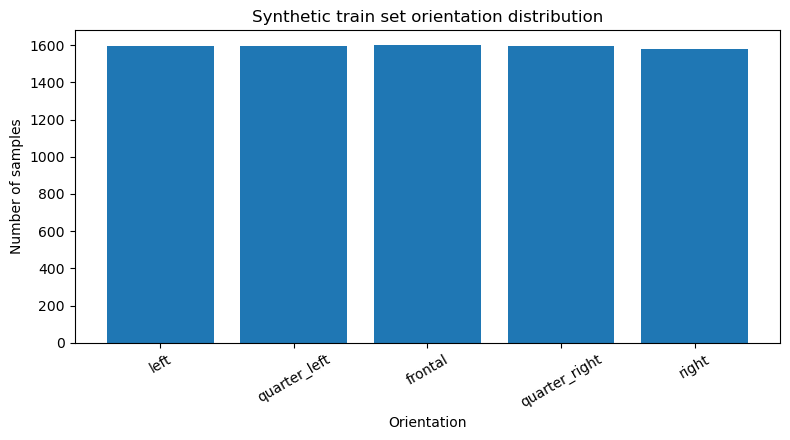

In [7]:
def plot_class_distribution(summary_df: pd.DataFrame, output_path: Path) -> None:
    """
    Plot sample count per class.

    Args:
        summary_df: DataFrame with class-level summary.
        output_path: Path where the plot will be saved.
    """
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(summary_df["class_name"], summary_df["n_samples"])
    ax.set_title("Synthetic train set orientation distribution")
    ax.set_xlabel("Orientation")
    ax.set_ylabel("Number of samples")
    ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

plot_class_distribution(summary_df, FIGURES_DIR / "orientation_distribution_train.png")


In [8]:
def compute_visibility_table(visibility: np.ndarray, class_indices: np.ndarray) -> pd.DataFrame:
    """
    Compute visibility rate by landmark and class.

    Args:
        visibility: Visibility array with shape [M, N].
        class_indices: Class index array with shape [M].

    Returns:
        DataFrame with landmark-level visibility rates by class.
    """
    rows = []
    for landmark_idx in range(visibility.shape[1]):
        for class_idx, class_name in CLASS_NAMES.items():
            mask = class_indices == class_idx
            rate = float(np.mean(visibility[mask, landmark_idx])) if np.any(mask) else np.nan
            rows.append(
                {
                    "landmark_idx": landmark_idx,
                    "landmark_number": landmark_idx + 1,
                    "anatomical_group": get_anatomical_group(landmark_idx),
                    "anatomical_label": get_anatomical_label(landmark_idx),
                    "class_idx": class_idx,
                    "class_name": class_name,
                    "visibility_rate": rate,
                }
            )
    return pd.DataFrame(rows)

visibility_table = compute_visibility_table(train_visibility, train_class_indices)
visibility_table.to_csv(TABLES_DIR / "visibility_rate_by_landmark_and_class.csv", index=False)
visibility_table.head()


,landmark_idx,landmark_number,anatomical_group,anatomical_label,class_idx,class_name,visibility_rate
0,0,1,face_contour,face_contour_1,0,left,0.000000
1,0,1,face_contour,face_contour_1,1,quarter_left,0.000000
2,0,1,face_contour,face_contour_1,2,frontal,0.063125
3,0,1,face_contour,face_contour_1,3,quarter_right,0.998123
4,0,1,face_contour,face_contour_1,4,right,1.000000


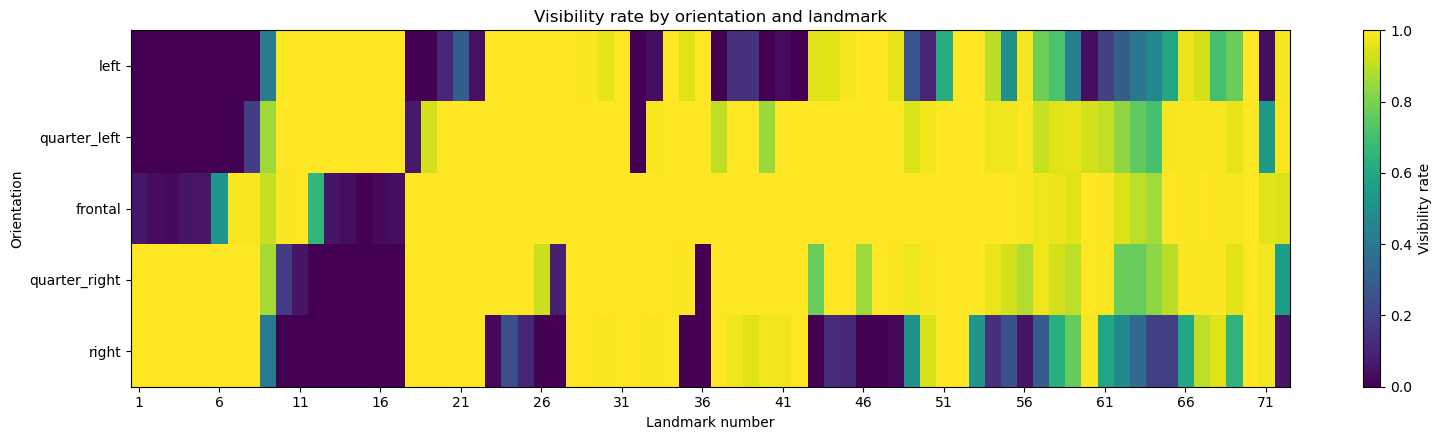

In [9]:
def plot_visibility_heatmap(visibility_table: pd.DataFrame, output_path: Path) -> None:
    """
    Plot visibility rate heatmap by class and landmark.

    Args:
        visibility_table: DataFrame returned by compute_visibility_table.
        output_path: Path where the plot will be saved.
    """
    pivot = visibility_table.pivot(index="class_name", columns="landmark_number", values="visibility_rate")
    pivot = pivot.loc[[CLASS_NAMES[idx] for idx in sorted(CLASS_NAMES)]]
    fig, ax = plt.subplots(figsize=(16, 4.5))
    image = ax.imshow(pivot.values, aspect="auto", vmin=0, vmax=1)
    ax.set_title("Visibility rate by orientation and landmark")
    ax.set_xlabel("Landmark number")
    ax.set_ylabel("Orientation")
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xticks(np.arange(0, NUM_LANDMARKS, 5))
    ax.set_xticklabels(np.arange(1, NUM_LANDMARKS + 1, 5))
    fig.colorbar(image, ax=ax, label="Visibility rate")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

plot_visibility_heatmap(visibility_table, FIGURES_DIR / "visibility_rate_heatmap_train.png")


## Shape normalization and Procrustes alignment

Two representations are compared:

1. **Center and scale normalization**: removes translation and scale, while preserving residual pose-specific geometry.
2. **Generalized Procrustes alignment**: removes translation, scale, and rotation relative to an estimated reference shape. Reflection is disabled by default.

The PCA fitting can be performed globally or separately by `class_idx`.

In [10]:
def center_scale_shape(shape: np.ndarray, eps: float = 1e-8) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    Center and scale-normalize a landmark shape.

    Args:
        shape: Landmark coordinates with shape [N, 2].
        eps: Numerical stability constant.

    Returns:
        A tuple with normalized shape and transformation metadata.
    """
    centroid = shape.mean(axis=0)
    centered = shape - centroid
    scale = float(np.sqrt(np.mean(np.sum(centered ** 2, axis=1))))
    scale = max(scale, eps)
    normalized = centered / scale
    return normalized, {"centroid": centroid, "scale": np.asarray(scale)}


def normalize_shapes_center_scale(shapes: np.ndarray) -> Tuple[np.ndarray, List[Dict[str, np.ndarray]]]:
    """
    Apply center-scale normalization to multiple shapes.

    Args:
        shapes: Array with shape [M, N, 2].

    Returns:
        Normalized shapes and per-sample metadata.
    """
    normalized_shapes = []
    metadata = []
    for shape in shapes:
        normalized, transform = center_scale_shape(shape)
        normalized_shapes.append(normalized)
        metadata.append(transform)
    return np.stack(normalized_shapes, axis=0), metadata


def orthogonal_procrustes_align(source: np.ndarray, target: np.ndarray, allow_reflection: bool = False, eps: float = 1e-8) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    Align one source shape to a target shape using similarity Procrustes.

    Args:
        source: Source shape with shape [N, 2].
        target: Target/reference shape with shape [N, 2].
        allow_reflection: Whether to allow reflection in the rotation matrix.
        eps: Numerical stability constant.

    Returns:
        A tuple with aligned source shape and transformation metadata.
    """
    source_center = source.mean(axis=0)
    target_center = target.mean(axis=0)
    source_centered = source - source_center
    target_centered = target - target_center
    source_scale = max(float(np.sqrt(np.sum(source_centered ** 2))), eps)
    target_scale = max(float(np.sqrt(np.sum(target_centered ** 2))), eps)
    source_norm = source_centered / source_scale
    target_norm = target_centered / target_scale
    covariance = source_norm.T @ target_norm
    left_singular, _, right_singular_t = np.linalg.svd(covariance)
    rotation = left_singular @ right_singular_t
    if not allow_reflection and np.linalg.det(rotation) < 0:
        left_singular[:, -1] *= -1
        rotation = left_singular @ right_singular_t
    aligned = source_norm @ rotation
    return aligned, {
        "source_center": source_center,
        "source_scale": np.asarray(source_scale),
        "target_center": target_center,
        "target_scale": np.asarray(target_scale),
        "rotation": rotation,
    }


def generalized_procrustes_align(shapes: np.ndarray, allow_reflection: bool = False, max_iterations: int = 50, tolerance: float = 1e-7) -> Tuple[np.ndarray, np.ndarray, List[Dict[str, np.ndarray]]]:
    """
    Align multiple shapes using generalized Procrustes analysis.

    Args:
        shapes: Array with shape [M, N, 2].
        allow_reflection: Whether to allow reflection in the alignment.
        max_iterations: Maximum number of iterations.
        tolerance: Convergence tolerance on reference shape update.

    Returns:
        A tuple with aligned shapes, reference mean shape, and per-sample transforms.
    """
    if shapes.ndim != 3 or shapes.shape[-1] != 2:
        raise ValueError(f"Expected shapes [M, N, 2], got {shapes.shape}.")

    centered_scaled, _ = normalize_shapes_center_scale(shapes)
    reference = centered_scaled.mean(axis=0)
    reference, _ = center_scale_shape(reference)
    aligned_shapes = centered_scaled
    final_transforms: List[Dict[str, np.ndarray]] = []

    for _ in range(max_iterations):
        aligned_list = []
        transforms = []
        for shape in shapes:
            aligned, transform = orthogonal_procrustes_align(shape, reference, allow_reflection=allow_reflection)
            aligned_list.append(aligned)
            transforms.append(transform)
        aligned_shapes = np.stack(aligned_list, axis=0)
        new_reference = aligned_shapes.mean(axis=0)
        new_reference, _ = center_scale_shape(new_reference)
        delta = float(np.linalg.norm(new_reference - reference))
        reference = new_reference
        final_transforms = transforms
        if delta < tolerance:
            break
    return aligned_shapes, reference, final_transforms


## PCA utilities

PCA is implemented using NumPy SVD to avoid external dependencies. Scores, reconstruction error, explained variance, and component visualization are all computed from the same representation.

In [11]:
@dataclass
class PCAResult:
    """
    Container for PCA results.

    Attributes:
        scope: Name of the PCA scope, for example 'global' or class name.
        class_idx: Optional class index for class-conditioned PCA.
        class_name: Optional class name for class-conditioned PCA.
        mean_vector: Mean shape vector with shape [D].
        components: Principal components with shape [K, D].
        explained_variance: Explained variance with shape [K].
        explained_variance_ratio: Explained variance ratio with shape [K].
        scores: PCA scores with shape [M, K].
        sample_indices: Original sample indices used to fit PCA.
        representation: Shape representation name.
    """
    scope: str
    class_idx: Optional[int]
    class_name: Optional[str]
    mean_vector: np.ndarray
    components: np.ndarray
    explained_variance: np.ndarray
    explained_variance_ratio: np.ndarray
    scores: np.ndarray
    sample_indices: np.ndarray
    representation: str


def flatten_shapes(shapes: np.ndarray) -> np.ndarray:
    """
    Flatten shape coordinates from [M, N, 2] to [M, 2N].

    Args:
        shapes: Array with shape [M, N, 2].

    Returns:
        Flattened array with shape [M, 2N].
    """
    return shapes.reshape(shapes.shape[0], -1)


def unflatten_shape_vectors(vectors: np.ndarray, num_landmarks: int = NUM_LANDMARKS) -> np.ndarray:
    """
    Convert flattened vectors into landmark shapes.

    Args:
        vectors: Array with shape [M, 2N] or [2N].
        num_landmarks: Number of landmarks.

    Returns:
        Array with shape [M, N, 2] or [N, 2].
    """
    array = np.asarray(vectors)
    if array.ndim == 1:
        return array.reshape(num_landmarks, 2)
    return array.reshape(array.shape[0], num_landmarks, 2)


def choose_num_components(singular_values: np.ndarray, n_samples: int, n_features: int, max_components: int = MAX_COMPONENTS_PER_PCA, explained_variance_threshold: float = EXPLAINED_VARIANCE_THRESHOLD) -> int:
    """
    Choose the number of PCA components using explained variance and safety limits.

    Args:
        singular_values: Singular values from SVD.
        n_samples: Number of samples.
        n_features: Number of features.
        max_components: Maximum allowed number of components.
        explained_variance_threshold: Cumulative variance threshold.

    Returns:
        Selected number of components.
    """
    if n_samples < 2:
        return 0
    explained_variance = (singular_values ** 2) / max(n_samples - 1, 1)
    total_variance = float(np.sum(explained_variance))
    if total_variance <= 0:
        return 0
    ratios = explained_variance / total_variance
    cumulative = np.cumsum(ratios)
    threshold_k = int(np.searchsorted(cumulative, explained_variance_threshold) + 1)
    safe_max = max(1, min(max_components, n_samples - 1, n_features))
    return int(min(threshold_k, safe_max))


def fit_pca(vectors: np.ndarray, scope: str, sample_indices: np.ndarray, representation: str, class_idx: Optional[int] = None, class_name: Optional[str] = None, max_components: int = MAX_COMPONENTS_PER_PCA, explained_variance_threshold: float = EXPLAINED_VARIANCE_THRESHOLD) -> PCAResult:
    """
    Fit PCA with SVD.

    Args:
        vectors: Input matrix with shape [M, D].
        scope: PCA scope name.
        sample_indices: Original sample indices used for fitting.
        representation: Shape representation name.
        class_idx: Optional class index.
        class_name: Optional class name.
        max_components: Maximum number of components.
        explained_variance_threshold: Cumulative explained variance target.

    Returns:
        PCAResult instance.
    """
    if vectors.ndim != 2:
        raise ValueError(f"Expected vectors [M, D], got {vectors.shape}.")
    n_samples, n_features = vectors.shape
    mean_vector = vectors.mean(axis=0)
    centered = vectors - mean_vector
    if n_samples < 2:
        return PCAResult(scope, class_idx, class_name, mean_vector, np.zeros((0, n_features)), np.zeros((0,)), np.zeros((0,)), np.zeros((n_samples, 0)), sample_indices, representation)
    _, singular_values, vt = np.linalg.svd(centered, full_matrices=False)
    k = choose_num_components(singular_values, n_samples, n_features, max_components, explained_variance_threshold)
    explained_variance_full = (singular_values ** 2) / max(n_samples - 1, 1)
    total_variance = float(np.sum(explained_variance_full))
    explained_ratio_full = explained_variance_full / total_variance if total_variance > 0 else np.zeros_like(explained_variance_full)
    components = vt[:k]
    scores = centered @ components.T
    return PCAResult(scope, class_idx, class_name, mean_vector, components, explained_variance_full[:k], explained_ratio_full[:k], scores, sample_indices, representation)


def reconstruct_from_pca(pca: PCAResult, vectors: np.ndarray) -> np.ndarray:
    """
    Reconstruct vectors from a PCA subspace.

    Args:
        pca: PCAResult instance.
        vectors: Input vectors with shape [M, D].

    Returns:
        Reconstructed vectors with shape [M, D].
    """
    if pca.components.shape[0] == 0:
        return np.repeat(pca.mean_vector[None, :], repeats=vectors.shape[0], axis=0)
    centered = vectors - pca.mean_vector
    scores = centered @ pca.components.T
    return pca.mean_vector + scores @ pca.components


def compute_reconstruction_error(vectors: np.ndarray, reconstructed: np.ndarray) -> np.ndarray:
    """
    Compute per-sample RMS reconstruction error.

    Args:
        vectors: Original vectors with shape [M, D].
        reconstructed: Reconstructed vectors with shape [M, D].

    Returns:
        RMS error per sample with shape [M].
    """
    return np.sqrt(np.mean((vectors - reconstructed) ** 2, axis=1))


## Build shape representations

This cell builds center-scale, global Procrustes, and class-conditioned Procrustes representations.

In [12]:
train_shapes_center_scale, center_scale_metadata = normalize_shapes_center_scale(train_landmarks)
train_vectors_center_scale = flatten_shapes(train_shapes_center_scale)

train_shapes_procrustes_global, global_procrustes_reference, global_procrustes_metadata = generalized_procrustes_align(
    train_landmarks,
    allow_reflection=ALLOW_REFLECTION,
    max_iterations=PROCRUSTES_MAX_ITERATIONS,
    tolerance=PROCRUSTES_TOLERANCE,
)
train_vectors_procrustes_global = flatten_shapes(train_shapes_procrustes_global)

print("Representations created:")
print(f"Center-scale vectors       : {train_vectors_center_scale.shape}")
print(f"Global Procrustes vectors  : {train_vectors_procrustes_global.shape}")


Representations created:
Center-scale vectors       : (7974, 144)
Global Procrustes vectors  : (7974, 144)


In [13]:
def build_class_conditioned_procrustes_representations(landmarks: np.ndarray, class_indices: np.ndarray) -> Tuple[np.ndarray, Dict[int, np.ndarray], Dict[int, List[Dict[str, np.ndarray]]]]:
    """
    Build class-conditioned Procrustes-aligned shape representation.

    Args:
        landmarks: Landmark array with shape [M, N, 2].
        class_indices: Class index array with shape [M].

    Returns:
        Tuple with aligned shapes [M, N, 2], class reference shapes, and transforms by class.
    """
    aligned_shapes = np.zeros_like(landmarks, dtype=np.float64)
    references: Dict[int, np.ndarray] = {}
    transforms_by_class: Dict[int, List[Dict[str, np.ndarray]]] = {}
    for class_idx in sorted(CLASS_NAMES):
        mask = class_indices == class_idx
        indices = np.where(mask)[0]
        if len(indices) == 0:
            continue
        class_shapes = landmarks[indices]
        aligned, reference, transforms = generalized_procrustes_align(class_shapes, allow_reflection=ALLOW_REFLECTION, max_iterations=PROCRUSTES_MAX_ITERATIONS, tolerance=PROCRUSTES_TOLERANCE)
        aligned_shapes[indices] = aligned
        references[class_idx] = reference
        transforms_by_class[class_idx] = transforms
    return aligned_shapes, references, transforms_by_class

train_shapes_procrustes_by_class, class_procrustes_references, class_procrustes_metadata = build_class_conditioned_procrustes_representations(train_landmarks, train_class_indices)
train_vectors_procrustes_by_class = flatten_shapes(train_shapes_procrustes_by_class)
print(f"Class-conditioned Procrustes vectors: {train_vectors_procrustes_by_class.shape}")


Class-conditioned Procrustes vectors: (7974, 144)


## Mean shapes and landmark variability

Mean shapes and variability are computed per class. These plots help identify whether face contour, chin, lips, or other groups are intrinsically more variable in the synthetic training set.

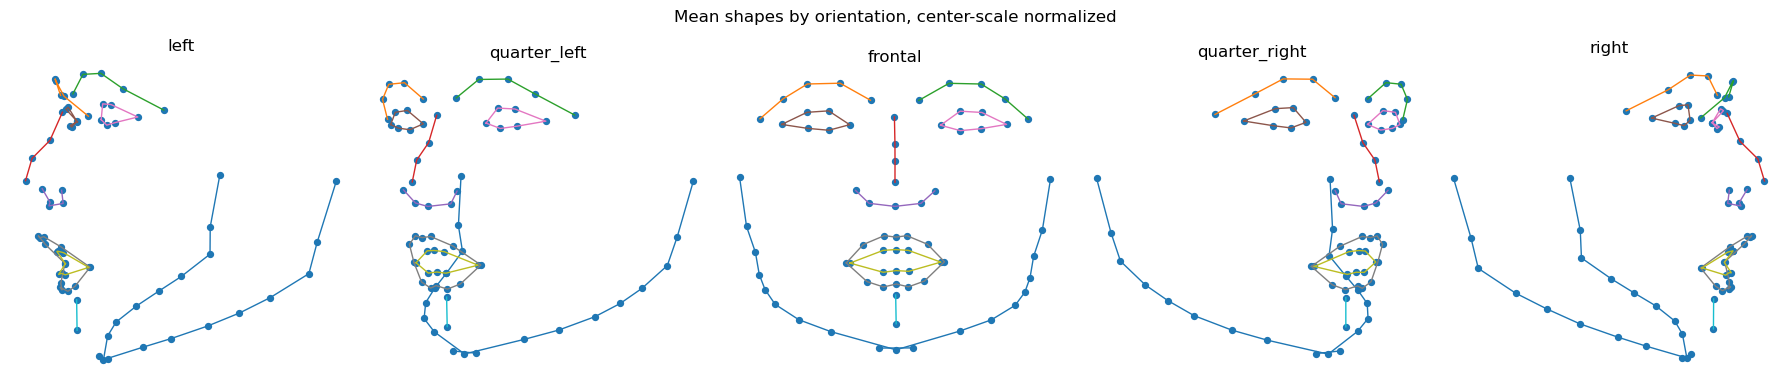

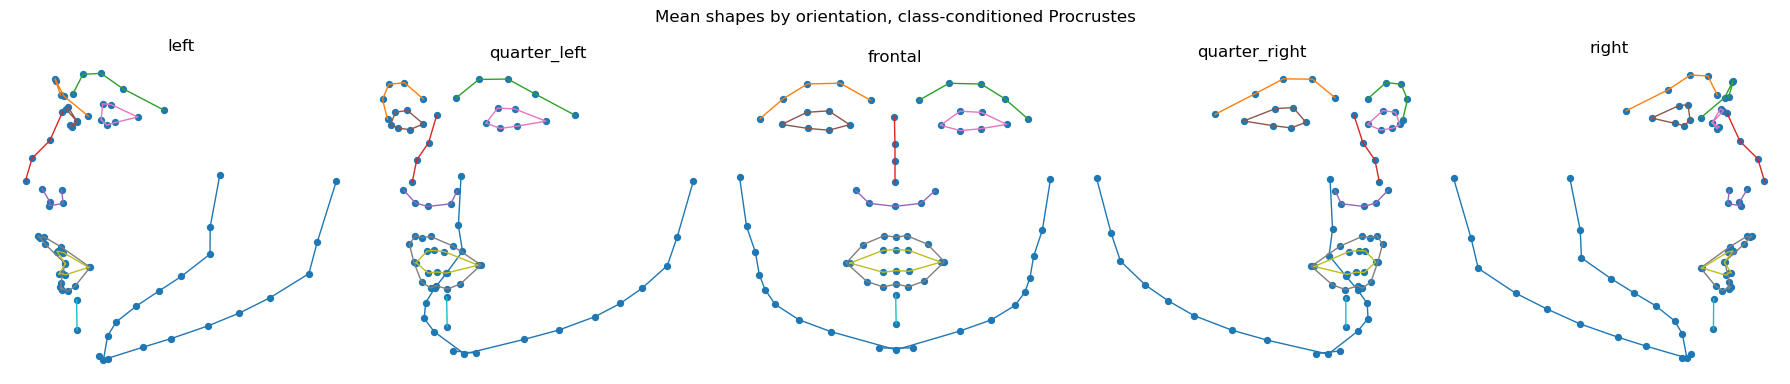

In [15]:
def plot_shape(ax: plt.Axes, shape: np.ndarray, title: str, point_size: int = 18, line_width: float = 1.0) -> None:
    """
    Plot a landmark shape with group-wise connections.

    Args:
        ax: Matplotlib axis.
        shape: Landmark coordinates with shape [N, 2].
        title: Axis title.
        point_size: Scatter point size.
        line_width: Connection line width.
    """
    groups = {
        "face_contour": list(range(0, 17)),
        "right_eyebrow": list(range(17, 22)),
        "left_eyebrow": list(range(22, 27)),
        "nose_bridge": list(range(27, 31)),
        "nose_base": list(range(31, 36)),
        "right_eye": [36, 37, 38, 39, 40, 41, 36],
        "left_eye": [42, 43, 44, 45, 46, 47, 42],
        "outer_lip": [48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 48],
        "inner_lip": [60, 61, 62, 63, 64, 65, 66, 67, 60],
        "upper_chin": [68, 69],
        "lower_chin": [70, 71],
    }
    for _, indices in groups.items():
        valid_indices = [idx for idx in indices if idx < shape.shape[0]]
        if len(valid_indices) >= 2:
            ax.plot(shape[valid_indices, 0], shape[valid_indices, 1], linewidth=line_width)
    ax.scatter(shape[:, 0], shape[:, 1], s=point_size)
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.axis("off")


def plot_mean_shapes_by_class(shapes: np.ndarray, class_indices: np.ndarray, output_path: Path, title: str) -> None:
    """
    Plot mean shape for each orientation class.

    Args:
        shapes: Shape array with shape [M, N, 2].
        class_indices: Class index array with shape [M].
        output_path: Path where the figure will be saved.
        title: Figure title.
    """
    fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(18, 4))
    for ax, class_idx in zip(axes, sorted(CLASS_NAMES)):
        mask = class_indices == class_idx
        if np.any(mask):
            mean_shape = shapes[mask].mean(axis=0)
            plot_shape(ax, mean_shape, CLASS_NAMES[class_idx])
        else:
            ax.set_title(f"{CLASS_NAMES[class_idx]}\n(no samples)")
            ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

plot_mean_shapes_by_class(train_shapes_center_scale, train_class_indices, FIGURES_DIR / "mean_shapes_by_class_center_scale.png", "Mean shapes by orientation, center-scale normalized")
plot_mean_shapes_by_class(train_shapes_procrustes_by_class, train_class_indices, FIGURES_DIR / "mean_shapes_by_class_procrustes_by_class.png", "Mean shapes by orientation, class-conditioned Procrustes")


In [16]:
def compute_landmark_variability(shapes: np.ndarray, visibility: np.ndarray, class_indices: np.ndarray, representation: str) -> pd.DataFrame:
    """
    Compute landmark variability by class and globally.

    Args:
        shapes: Shape array with shape [M, N, 2].
        visibility: Visibility array with shape [M, N].
        class_indices: Class indices with shape [M].
        representation: Name of the representation.

    Returns:
        DataFrame with landmark variability statistics.
    """
    rows = []
    scopes = [("global", None, np.ones(len(shapes), dtype=bool))]
    for class_idx, class_name in CLASS_NAMES.items():
        scopes.append((class_name, class_idx, class_indices == class_idx))
    for scope_name, class_idx, mask in scopes:
        if not np.any(mask):
            continue
        scope_shapes = shapes[mask]
        scope_visibility = visibility[mask]
        for landmark_idx in range(shapes.shape[1]):
            coords = scope_shapes[:, landmark_idx, :]
            std_x = float(np.std(coords[:, 0]))
            std_y = float(np.std(coords[:, 1]))
            spatial_std = float(np.sqrt(std_x ** 2 + std_y ** 2))
            rows.append(
                {
                    "representation": representation,
                    "scope": scope_name,
                    "class_idx": class_idx,
                    "landmark_idx": landmark_idx,
                    "landmark_number": landmark_idx + 1,
                    "anatomical_group": get_anatomical_group(landmark_idx),
                    "anatomical_label": get_anatomical_label(landmark_idx),
                    "mean_x": float(np.mean(coords[:, 0])),
                    "mean_y": float(np.mean(coords[:, 1])),
                    "std_x": std_x,
                    "std_y": std_y,
                    "spatial_std": spatial_std,
                    "visibility_rate": float(np.mean(scope_visibility[:, landmark_idx])),
                    "n_samples": int(scope_shapes.shape[0]),
                }
            )
    return pd.DataFrame(rows)

variability_center_scale = compute_landmark_variability(train_shapes_center_scale, train_visibility, train_class_indices, representation="center_scale")
variability_procrustes = compute_landmark_variability(train_shapes_procrustes_by_class, train_visibility, train_class_indices, representation="class_procrustes")
landmark_variability = pd.concat([variability_center_scale, variability_procrustes], ignore_index=True)
landmark_variability.to_csv(TABLES_DIR / "landmark_variability.csv", index=False)
landmark_variability.query("scope == 'global' and representation == 'center_scale'").sort_values("spatial_std", ascending=False).head(15)


,representation,scope,class_idx,landmark_idx,landmark_number,anatomical_group,anatomical_label,mean_x,mean_y,std_x,std_y,spatial_std,visibility_rate,n_samples
0,center_scale,global,NaN,0,1,face_contour,face_contour_1,-0.912051,-0.327647,1.240222,0.102733,1.244469,0.411086,7974
16,center_scale,global,NaN,16,17,face_contour,face_contour_17,0.912826,-0.303773,1.238938,0.086549,1.241957,0.406948,7974
1,center_scale,global,NaN,1,2,face_contour,face_contour_2,-0.863757,0.150539,1.149969,0.111829,1.155393,0.405568,7974
15,center_scale,global,NaN,15,16,face_contour,face_contour_16,0.857389,0.183987,1.139674,0.101011,1.144141,0.405819,7974
2,center_scale,global,NaN,2,3,face_contour,face_contour_3,-0.810673,0.398762,1.120614,0.098854,1.124965,0.403812,7974
14,center_scale,global,NaN,14,15,face_contour,face_contour_15,0.804267,0.438281,1.103996,0.097387,1.108283,0.401806,7974
3,center_scale,global,NaN,3,4,face_contour,face_contour_4,-0.772434,0.606484,0.910426,0.092593,0.915122,0.409205,7974
13,center_scale,global,NaN,13,14,face_contour,face_contour_14,0.766692,0.636845,0.886217,0.096137,0.891417,0.407825,7974
4,center_scale,global,NaN,4,5,face_contour,face_contour_5,-0.727395,0.743389,0.739526,0.094565,0.745547,0.411211,7974
12,center_scale,global,NaN,12,13,face_contour,face_contour_13,0.724949,0.769059,0.717862,0.098632,0.724606,0.411713,7974


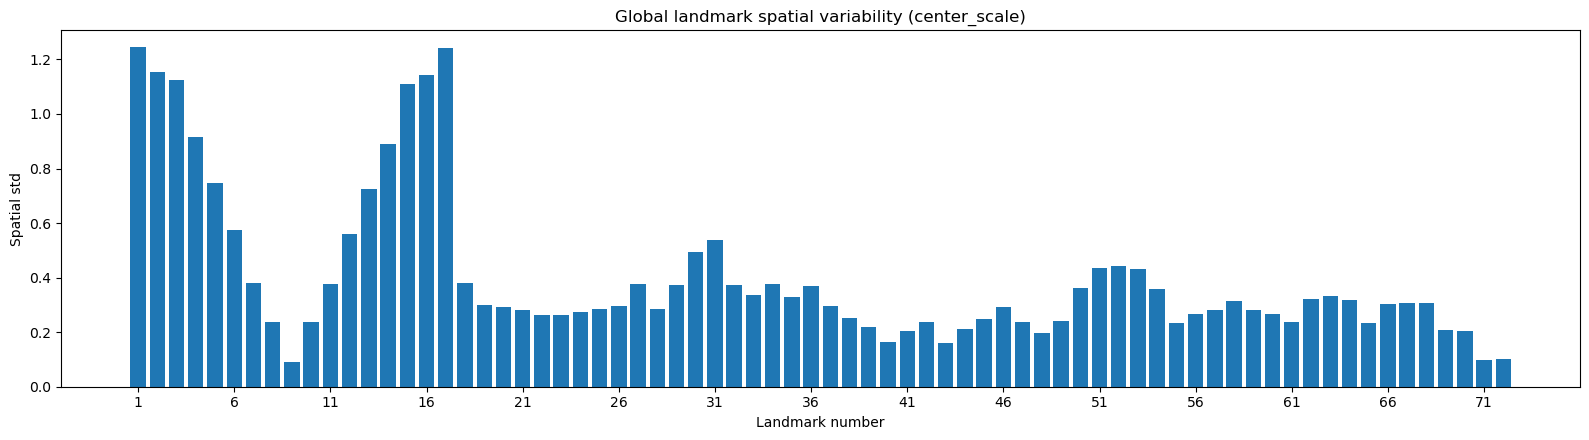

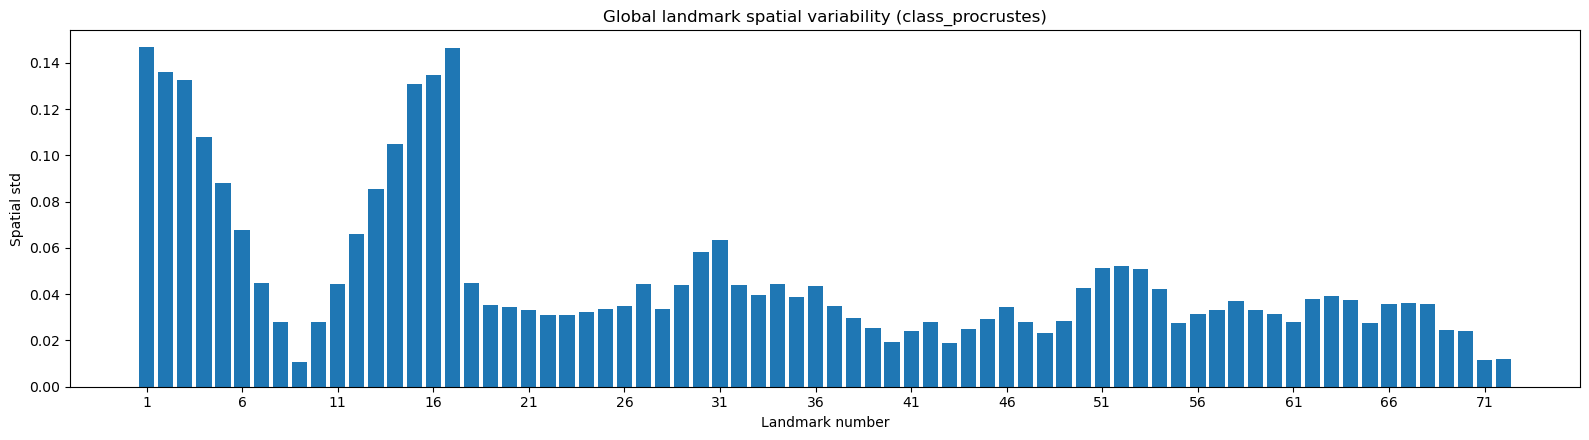

In [17]:
def plot_landmark_variability(variability_df: pd.DataFrame, representation: str, output_path: Path) -> None:
    """
    Plot global landmark spatial variability by landmark.

    Args:
        variability_df: Landmark variability DataFrame.
        representation: Representation name to plot.
        output_path: Path where the figure will be saved.
    """
    subset = variability_df.query("scope == 'global' and representation == @representation").copy()
    subset = subset.sort_values("landmark_idx")
    fig, ax = plt.subplots(figsize=(16, 4.5))
    ax.bar(subset["landmark_number"], subset["spatial_std"])
    ax.set_title(f"Global landmark spatial variability ({representation})")
    ax.set_xlabel("Landmark number")
    ax.set_ylabel("Spatial std")
    ax.set_xticks(np.arange(1, NUM_LANDMARKS + 1, 5))
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

plot_landmark_variability(landmark_variability, "center_scale", FIGURES_DIR / "landmark_variability_center_scale.png")
plot_landmark_variability(landmark_variability, "class_procrustes", FIGURES_DIR / "landmark_variability_class_procrustes.png")


## PCA fitting: global and class-conditioned

This section fits three PCA families:

1. Global PCA, center-scale representation.
2. Global PCA, global Procrustes representation.
3. Class-conditioned PCA, class-conditioned Procrustes representation.

In [18]:
def fit_global_and_class_pcas(vectors: np.ndarray, class_indices: np.ndarray, representation: str) -> Dict[str, PCAResult]:
    """
    Fit global and class-conditioned PCA models.

    Args:
        vectors: Shape vectors with shape [M, D].
        class_indices: Class index array with shape [M].
        representation: Representation name.

    Returns:
        Dictionary of PCAResult objects keyed by scope.
    """
    pcas: Dict[str, PCAResult] = {}
    all_indices = np.arange(vectors.shape[0])
    pcas[f"global__{representation}"] = fit_pca(vectors, "global", all_indices, representation)
    for class_idx, class_name in CLASS_NAMES.items():
        mask = class_indices == class_idx
        indices = np.where(mask)[0]
        if len(indices) < 2:
            warnings.warn(f"Skipping PCA for class {class_name}: fewer than 2 samples.")
            continue
        pcas[f"{class_name}__{representation}"] = fit_pca(vectors[indices], class_name, indices, representation, class_idx=class_idx, class_name=class_name)
    return pcas

pca_results: Dict[str, PCAResult] = {}
pca_results.update(fit_global_and_class_pcas(train_vectors_center_scale, train_class_indices, "center_scale"))
pca_results.update(fit_global_and_class_pcas(train_vectors_procrustes_global, train_class_indices, "global_procrustes"))
pca_results.update(fit_global_and_class_pcas(train_vectors_procrustes_by_class, train_class_indices, "class_procrustes"))

print(f"Fitted {len(pca_results)} PCA models.")
list(pca_results.keys())[:10]


Fitted 18 PCA models.


['global__center_scale',
 'left__center_scale',
 'quarter_left__center_scale',
 'frontal__center_scale',
 'quarter_right__center_scale',
 'right__center_scale',
 'global__global_procrustes',
 'left__global_procrustes',
 'quarter_left__global_procrustes',
 'frontal__global_procrustes']

In [19]:
def pca_explained_variance_table(pcas: Dict[str, PCAResult]) -> pd.DataFrame:
    """
    Build explained variance table for PCA models.

    Args:
        pcas: Dictionary of PCAResult objects.

    Returns:
        DataFrame with one row per component.
    """
    rows = []
    for key, pca in pcas.items():
        cumulative = np.cumsum(pca.explained_variance_ratio)
        for pc_idx, (variance, ratio, cumulative_ratio) in enumerate(zip(pca.explained_variance, pca.explained_variance_ratio, cumulative), start=1):
            rows.append(
                {
                    "pca_key": key,
                    "scope": pca.scope,
                    "class_idx": pca.class_idx,
                    "class_name": pca.class_name,
                    "representation": pca.representation,
                    "pc_idx": pc_idx,
                    "explained_variance": float(variance),
                    "explained_variance_ratio": float(ratio),
                    "cumulative_explained_variance_ratio": float(cumulative_ratio),
                    "n_samples": int(len(pca.sample_indices)),
                    "n_components": int(pca.components.shape[0]),
                }
            )
    return pd.DataFrame(rows)

explained_variance_df = pca_explained_variance_table(pca_results)
explained_variance_df.to_csv(TABLES_DIR / "pca_explained_variance.csv", index=False)
explained_variance_df.head()


,pca_key,scope,class_idx,class_name,representation,pc_idx,explained_variance,explained_variance_ratio,cumulative_explained_variance_ratio,n_samples,n_components
0,global__center_scale,global,NaN,None,center_scale,1,14.167802,0.828570,0.828570,7974,2
1,global__center_scale,global,NaN,None,center_scale,2,2.518597,0.147294,0.975864,7974,2
2,left__center_scale,left,0.0,left,center_scale,1,0.222191,0.405848,0.405848,1596,14
3,left__center_scale,left,0.0,left,center_scale,2,0.098612,0.180122,0.585970,1596,14
4,left__center_scale,left,0.0,left,center_scale,3,0.042451,0.077539,0.663509,1596,14


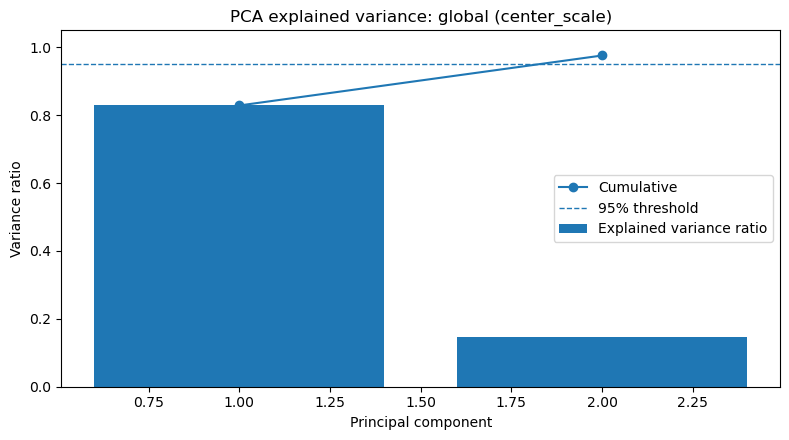

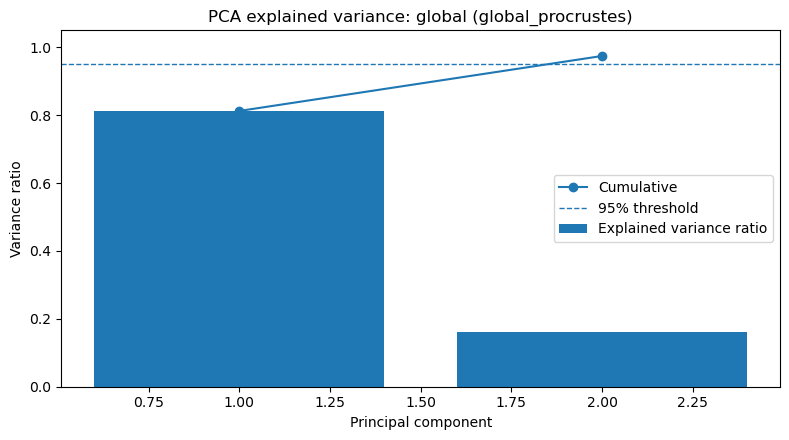

In [20]:
def plot_explained_variance(pca: PCAResult, output_path: Path) -> None:
    """
    Plot explained variance ratio and cumulative explained variance for one PCA.

    Args:
        pca: PCAResult instance.
        output_path: Path where the figure will be saved.
    """
    if pca.components.shape[0] == 0:
        return
    pc_numbers = np.arange(1, len(pca.explained_variance_ratio) + 1)
    cumulative = np.cumsum(pca.explained_variance_ratio)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(pc_numbers, pca.explained_variance_ratio, label="Explained variance ratio")
    ax.plot(pc_numbers, cumulative, marker="o", label="Cumulative")
    ax.axhline(EXPLAINED_VARIANCE_THRESHOLD, linestyle="--", linewidth=1.0, label=f"{EXPLAINED_VARIANCE_THRESHOLD:.0%} threshold")
    ax.set_title(f"PCA explained variance: {pca.scope} ({pca.representation})")
    ax.set_xlabel("Principal component")
    ax.set_ylabel("Variance ratio")
    ax.set_ylim(0, 1.05)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

for key in ["global__center_scale", "global__global_procrustes"]:
    if key in pca_results:
        plot_explained_variance(pca_results[key], FIGURES_DIR / f"explained_variance_{key}.png")


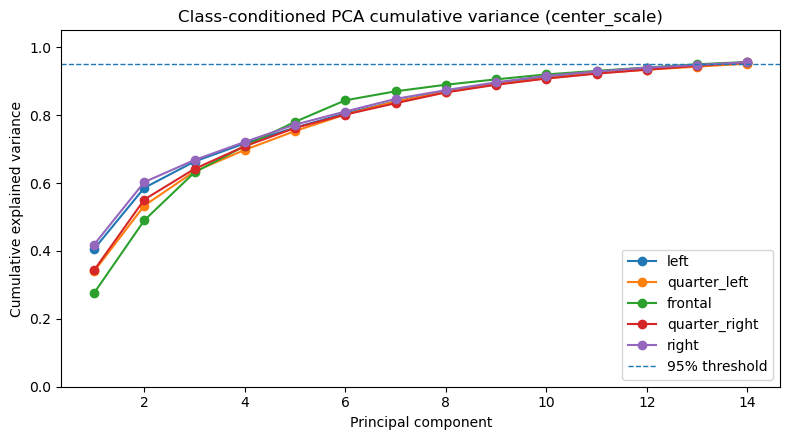

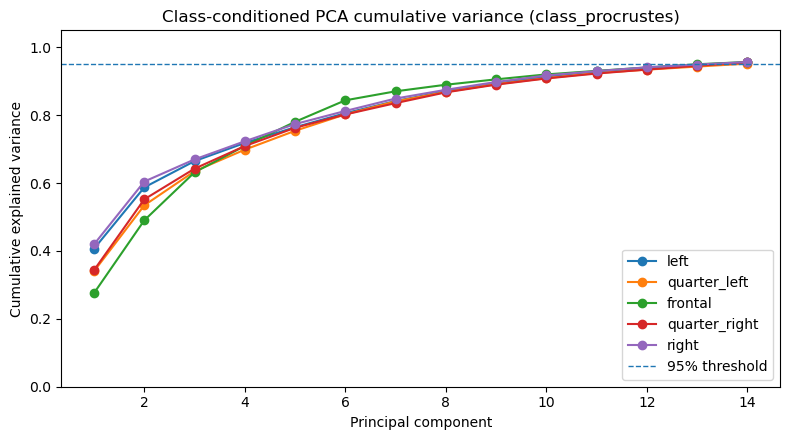

In [21]:
def plot_explained_variance_by_class(representation: str, output_path: Path) -> None:
    """
    Plot cumulative explained variance for class-conditioned PCA models.

    Args:
        representation: PCA representation name.
        output_path: Path where the figure will be saved.
    """
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for class_idx, class_name in CLASS_NAMES.items():
        key = f"{class_name}__{representation}"
        if key not in pca_results:
            continue
        pca = pca_results[key]
        if pca.components.shape[0] == 0:
            continue
        pc_numbers = np.arange(1, len(pca.explained_variance_ratio) + 1)
        cumulative = np.cumsum(pca.explained_variance_ratio)
        ax.plot(pc_numbers, cumulative, marker="o", label=class_name)
    ax.axhline(EXPLAINED_VARIANCE_THRESHOLD, linestyle="--", linewidth=1.0, label=f"{EXPLAINED_VARIANCE_THRESHOLD:.0%} threshold")
    ax.set_title(f"Class-conditioned PCA cumulative variance ({representation})")
    ax.set_xlabel("Principal component")
    ax.set_ylabel("Cumulative explained variance")
    ax.set_ylim(0, 1.05)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

plot_explained_variance_by_class("center_scale", FIGURES_DIR / "class_pca_cumulative_variance_center_scale.png")
plot_explained_variance_by_class("class_procrustes", FIGURES_DIR / "class_pca_cumulative_variance_class_procrustes.png")


## Visualize PCA components

Each component plot shows `mean - alpha * sqrt(lambda) * PC`, `mean`, and `mean + alpha * sqrt(lambda) * PC`.

Use these figures to interpret whether a component captures yaw, contour deformation, mouth opening, chin variation, or other shape changes.

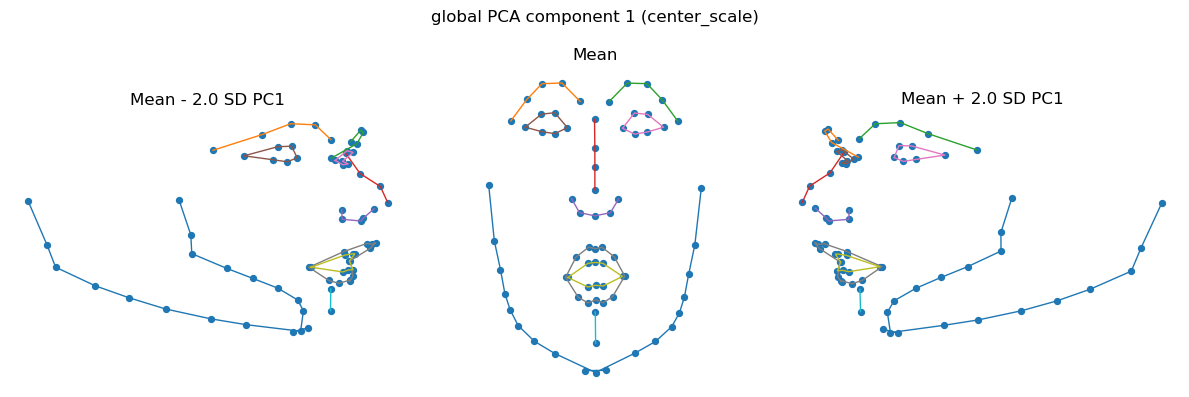

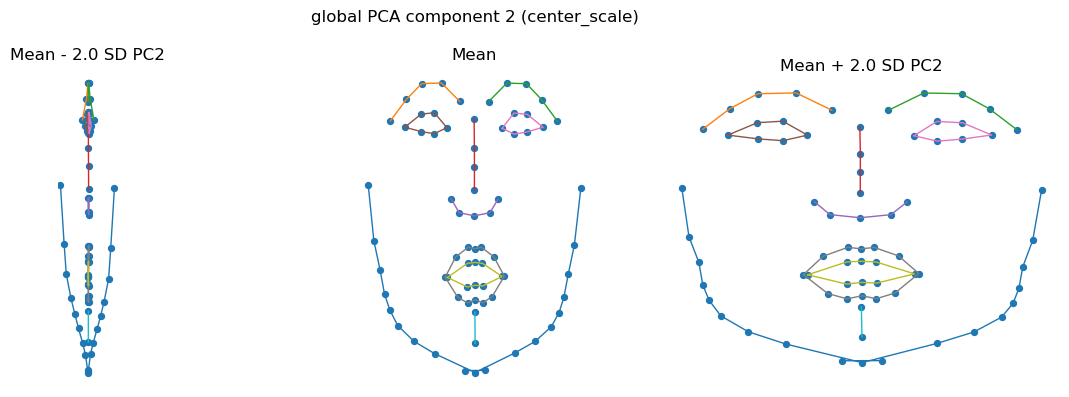

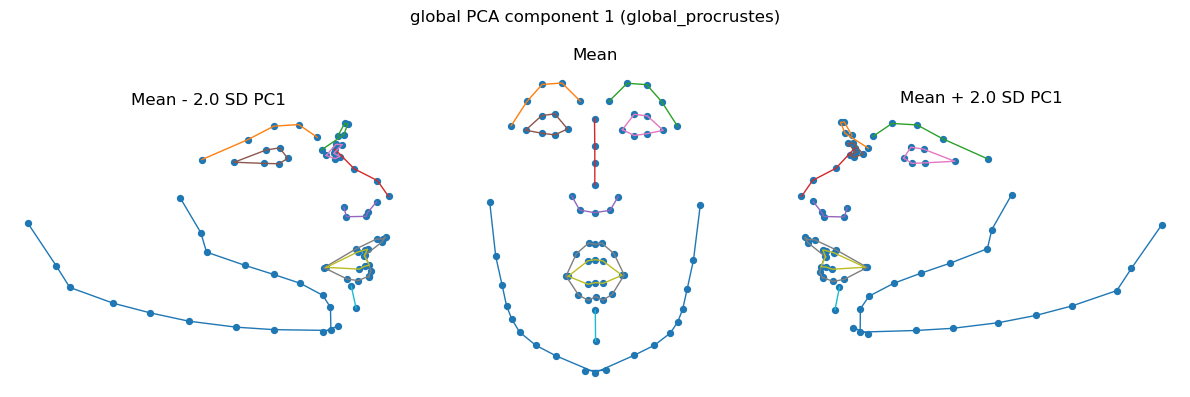

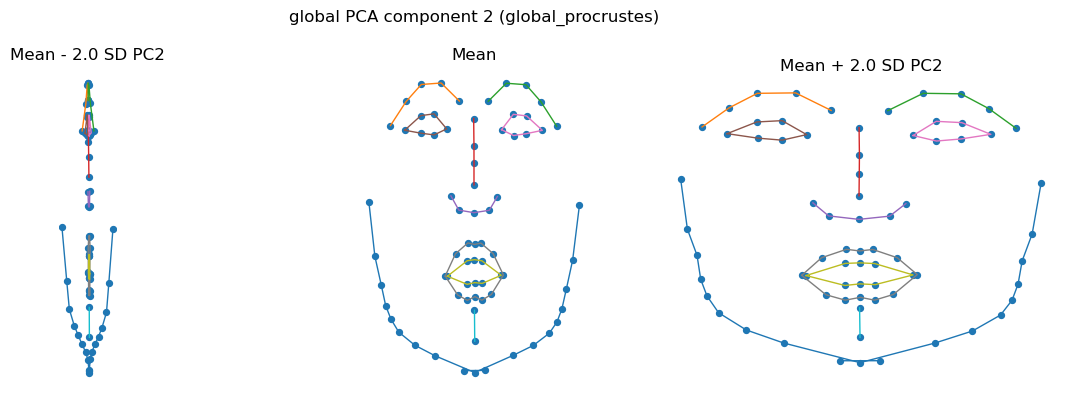

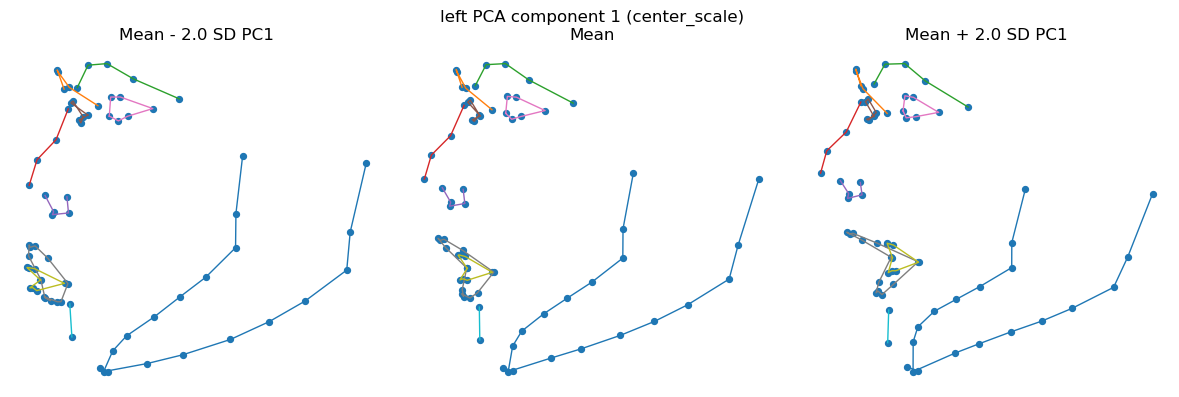

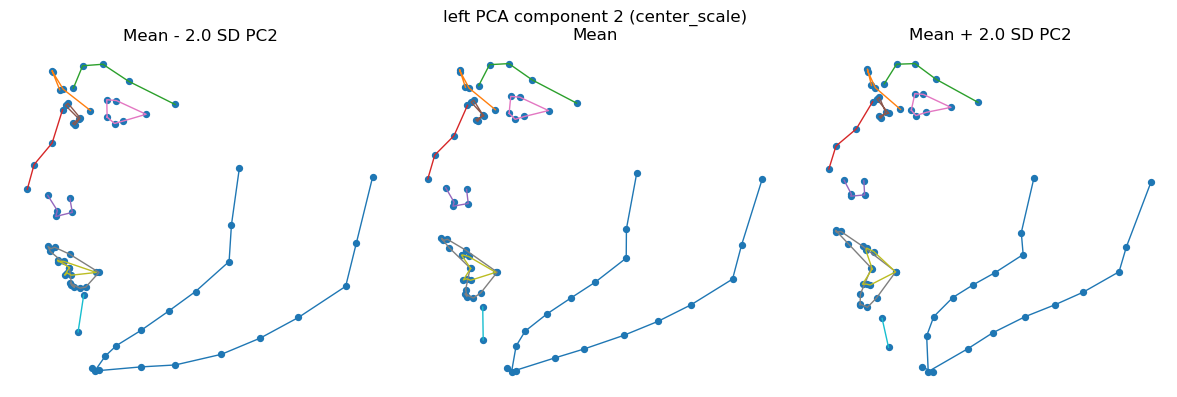

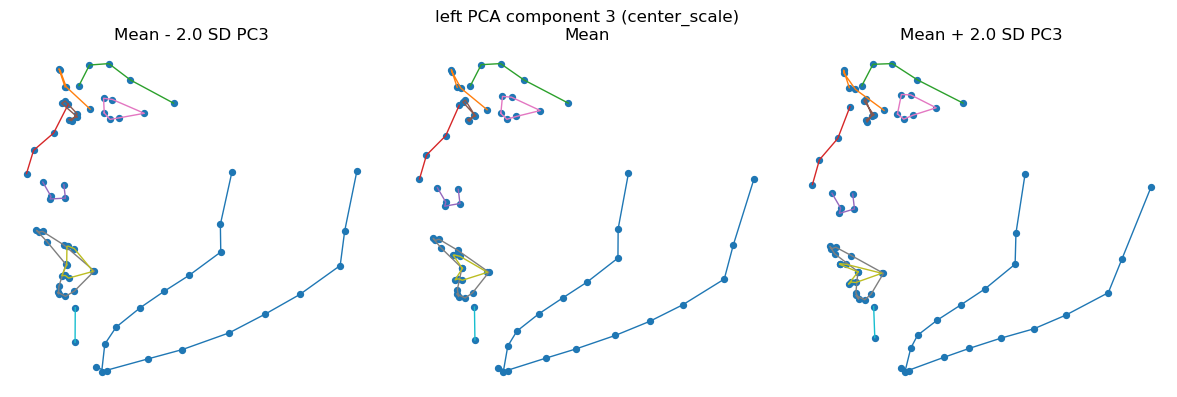

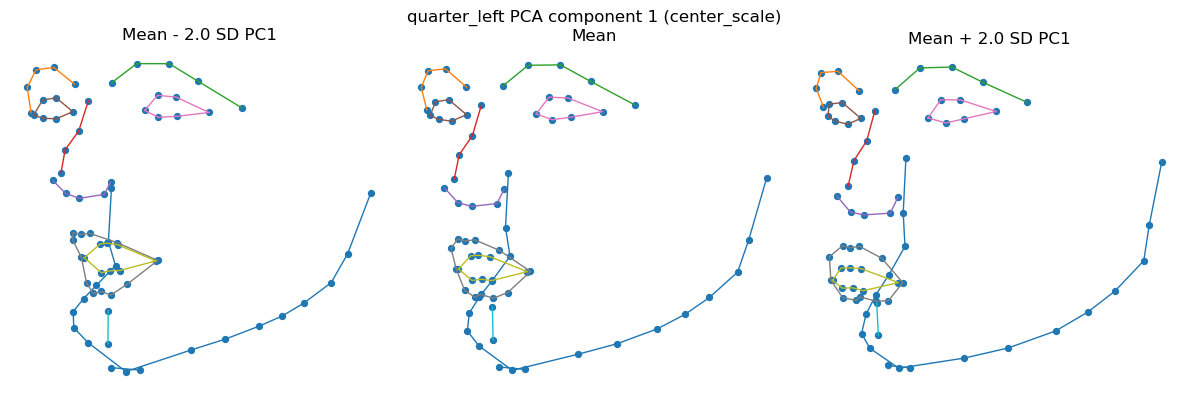

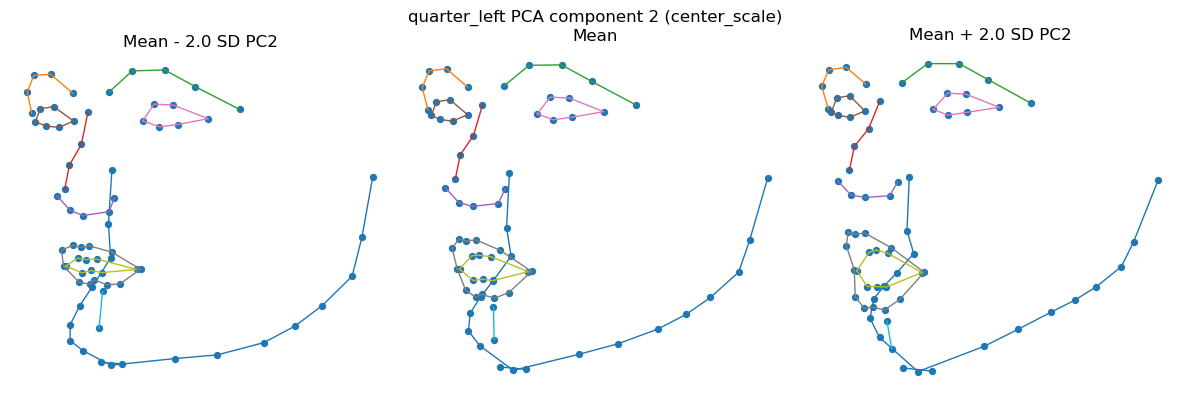

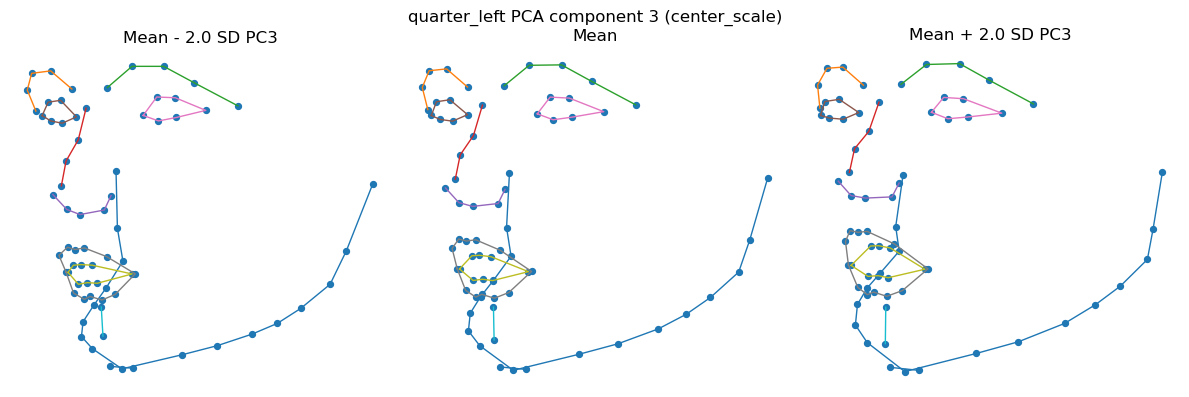

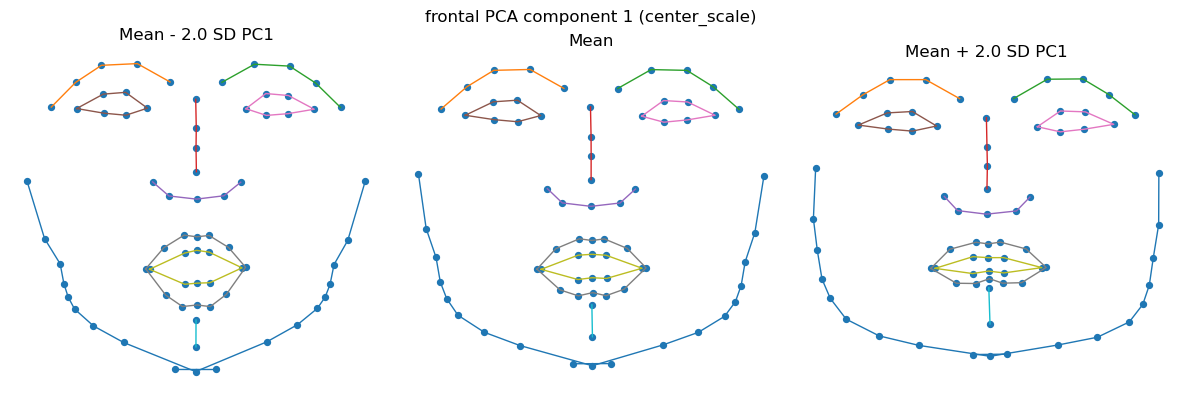

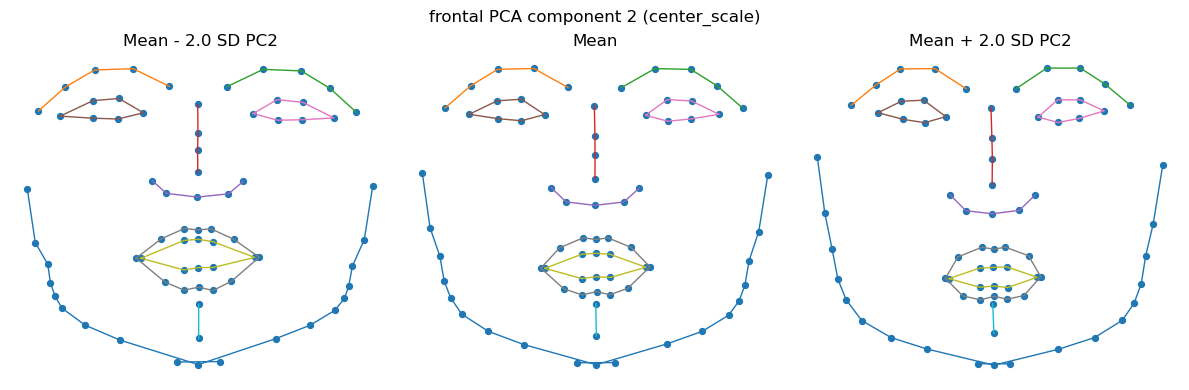

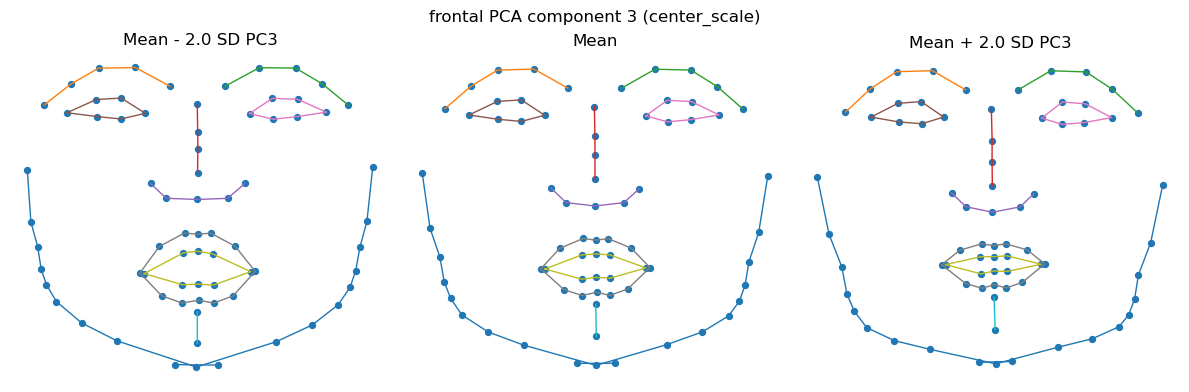

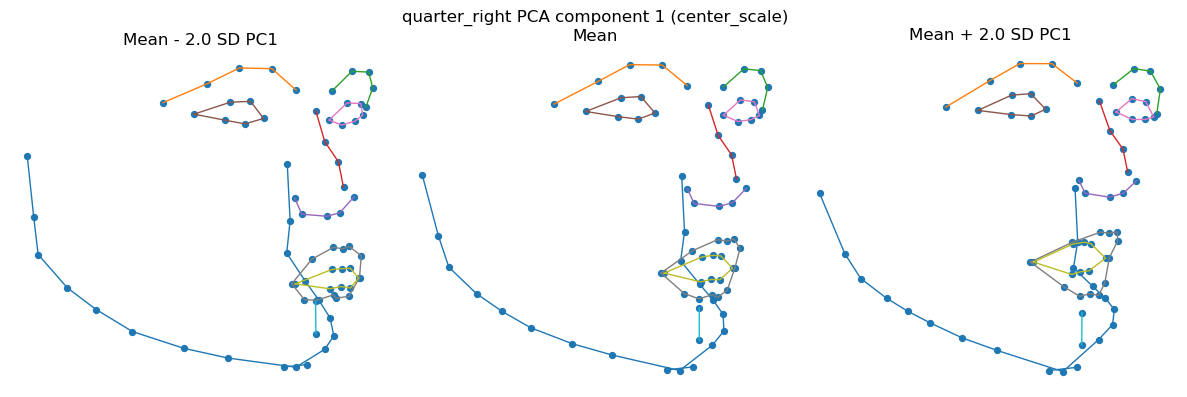

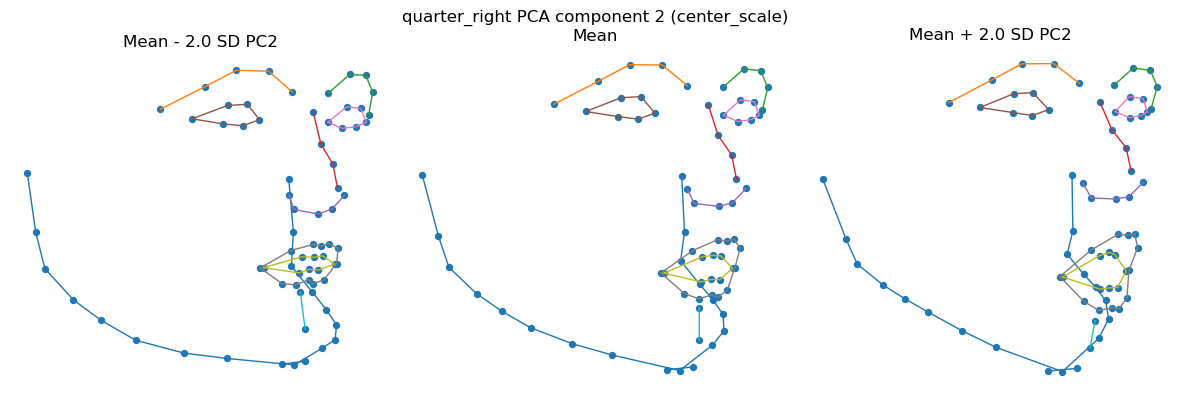

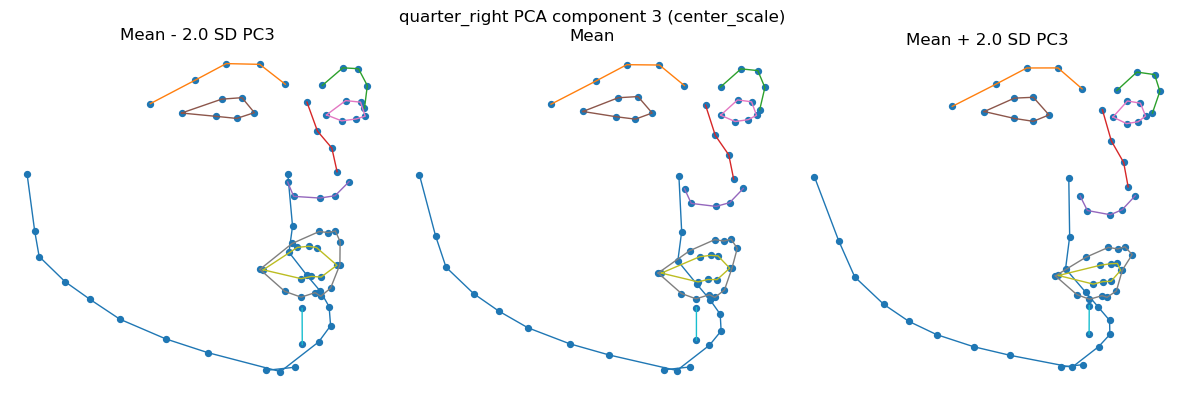

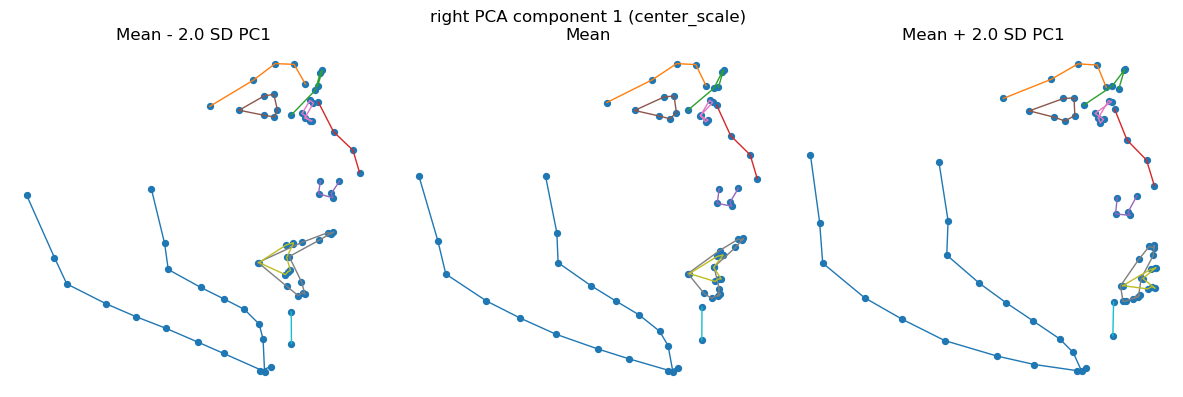

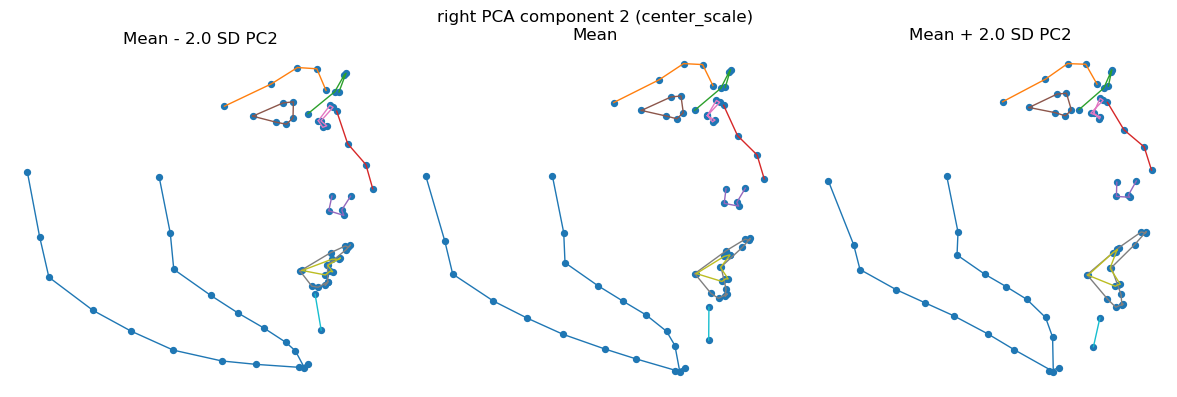

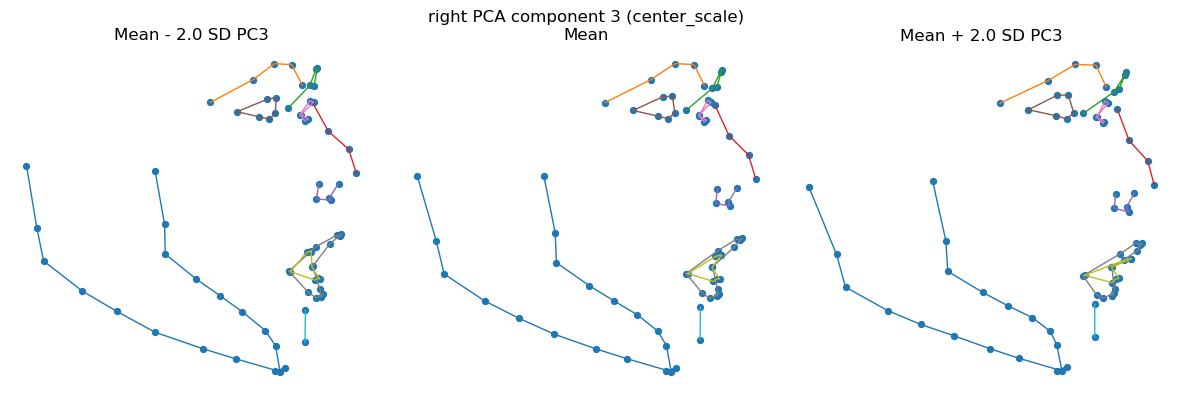

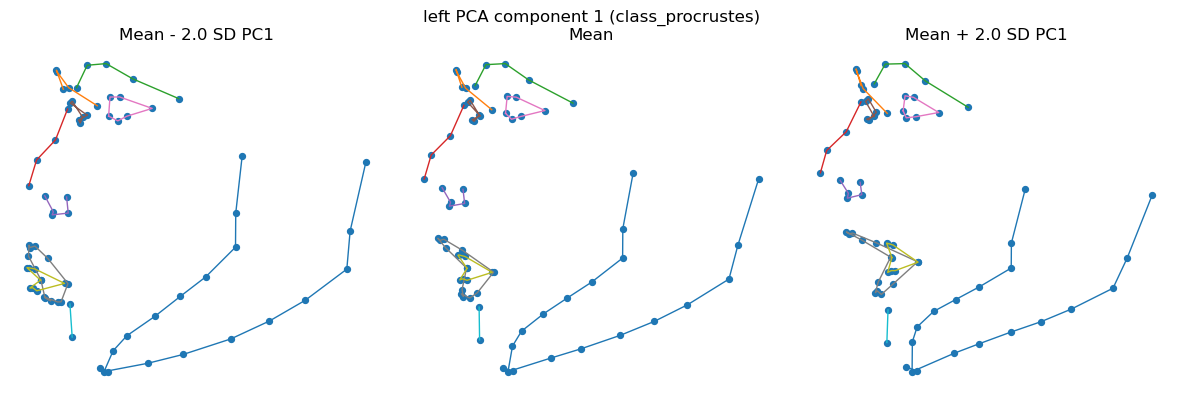

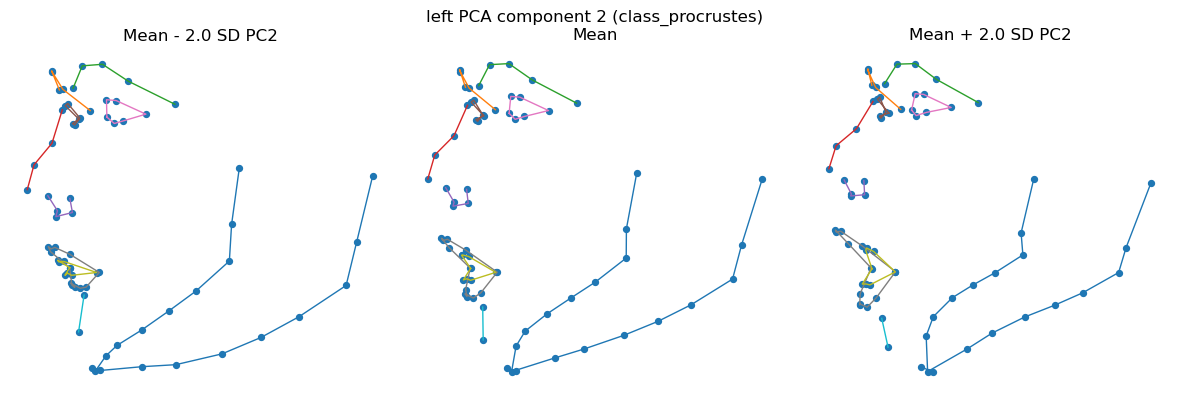

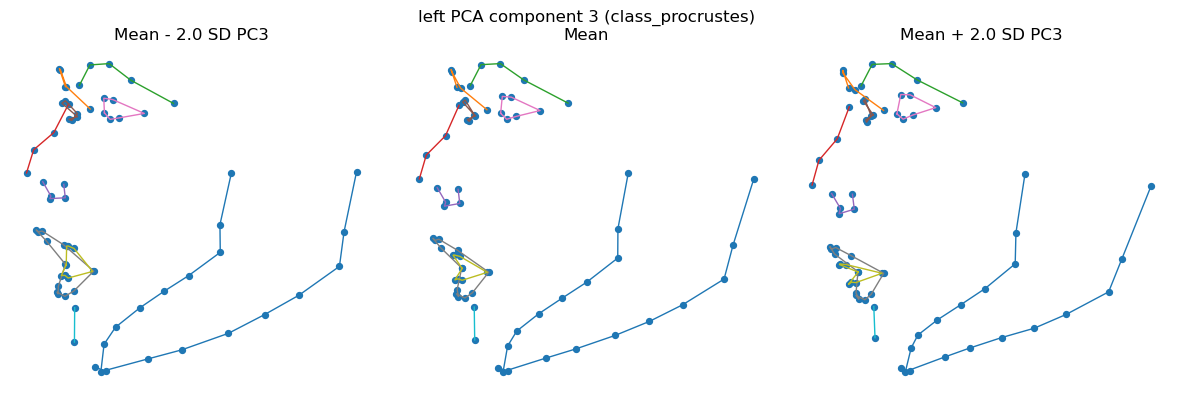

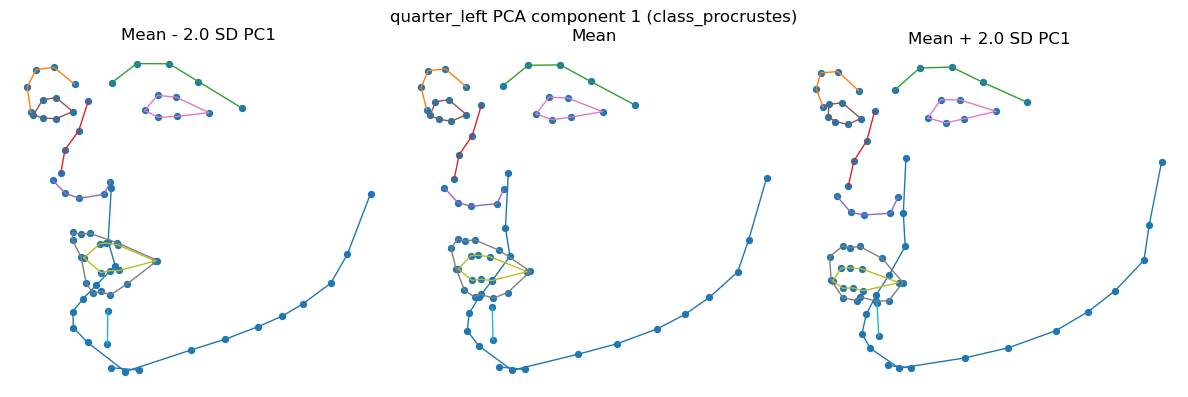

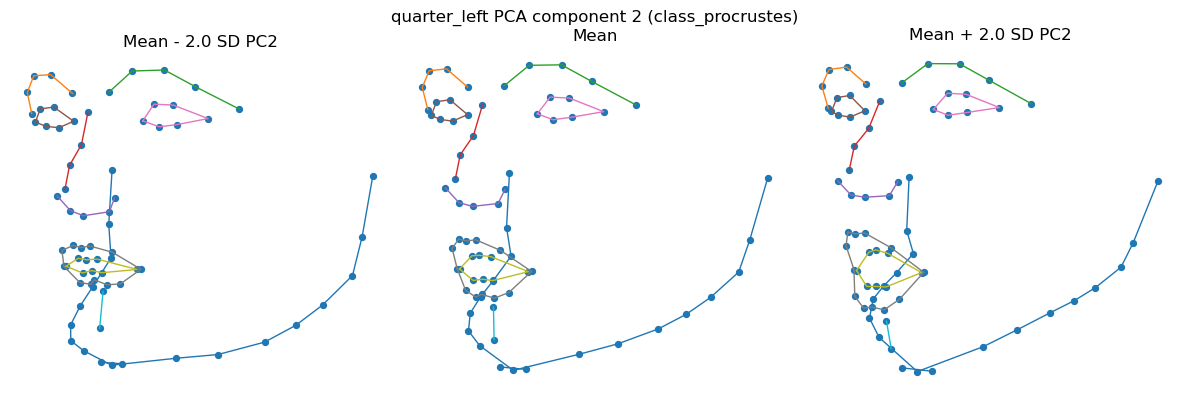

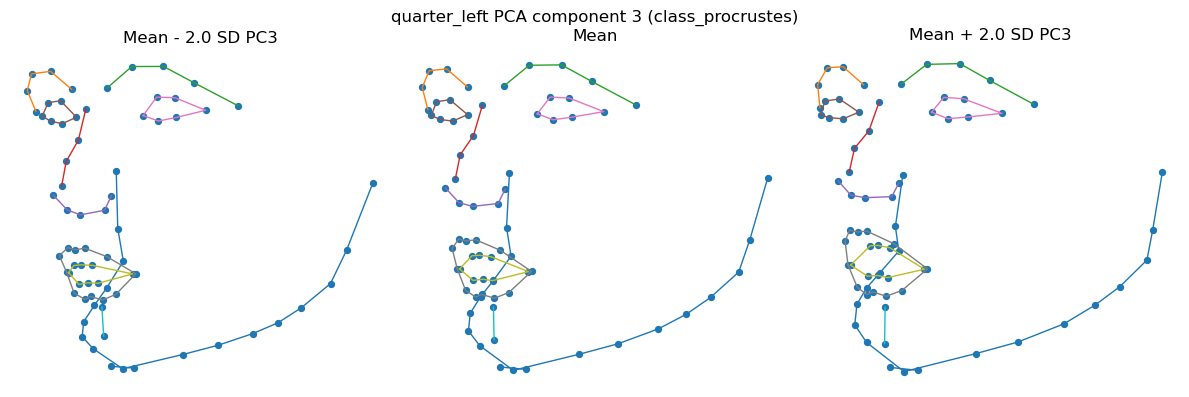

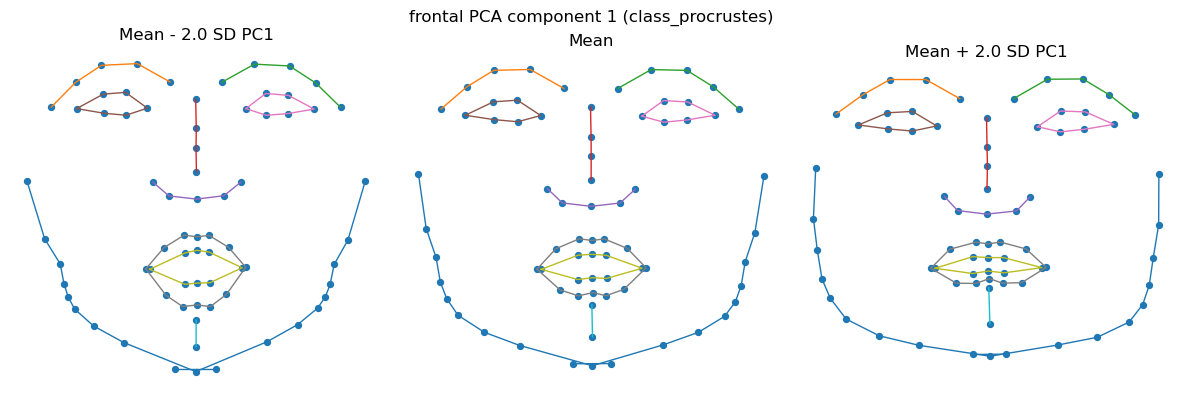

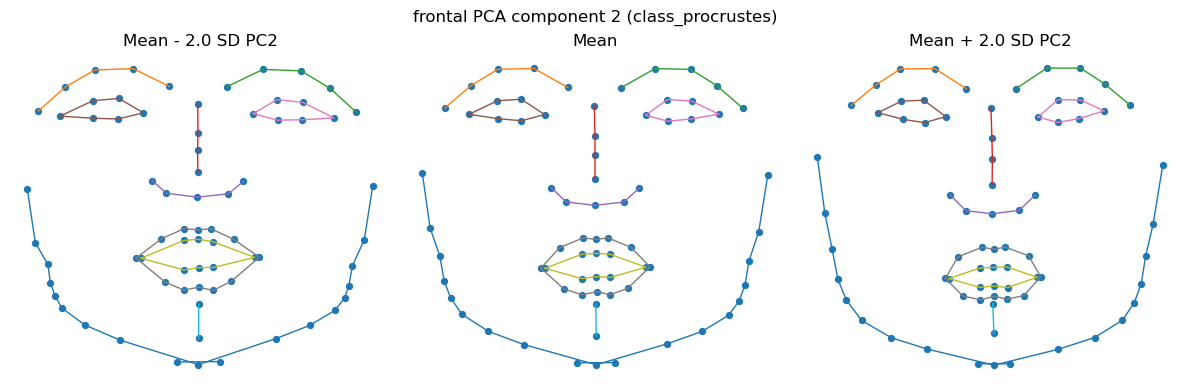

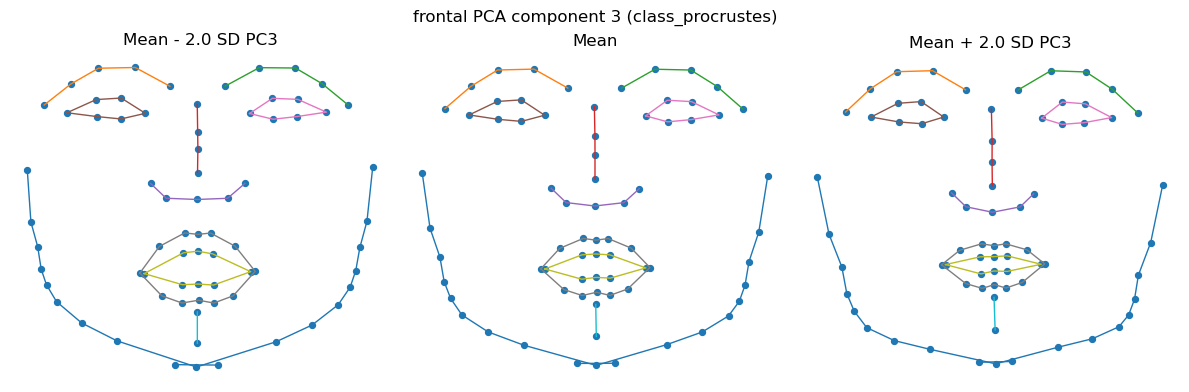

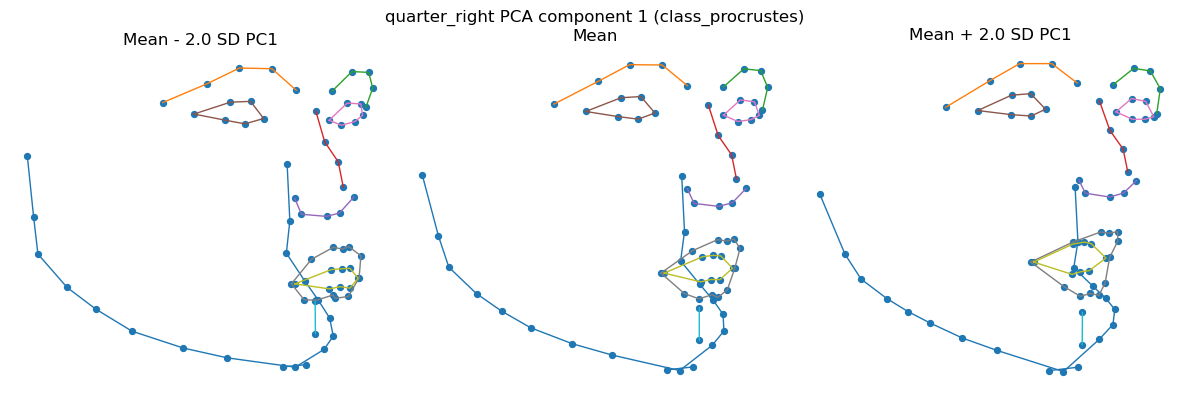

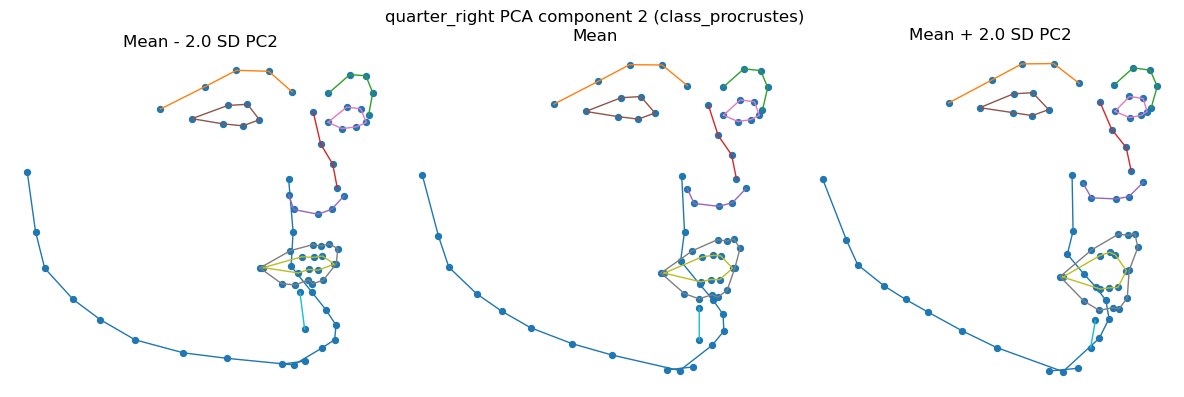

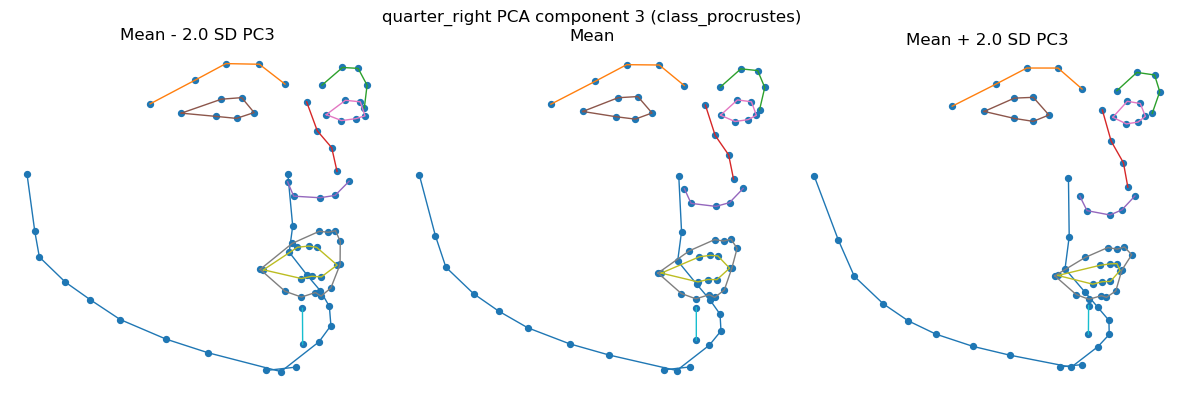

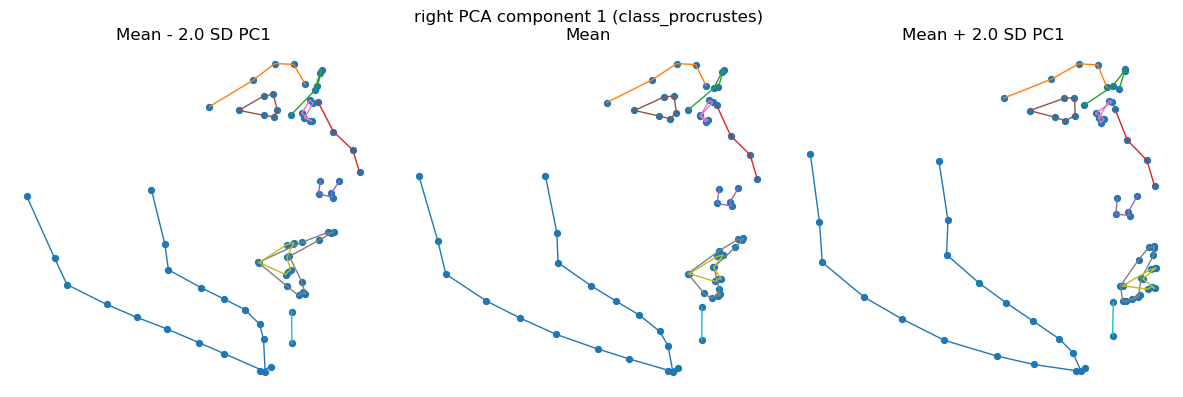

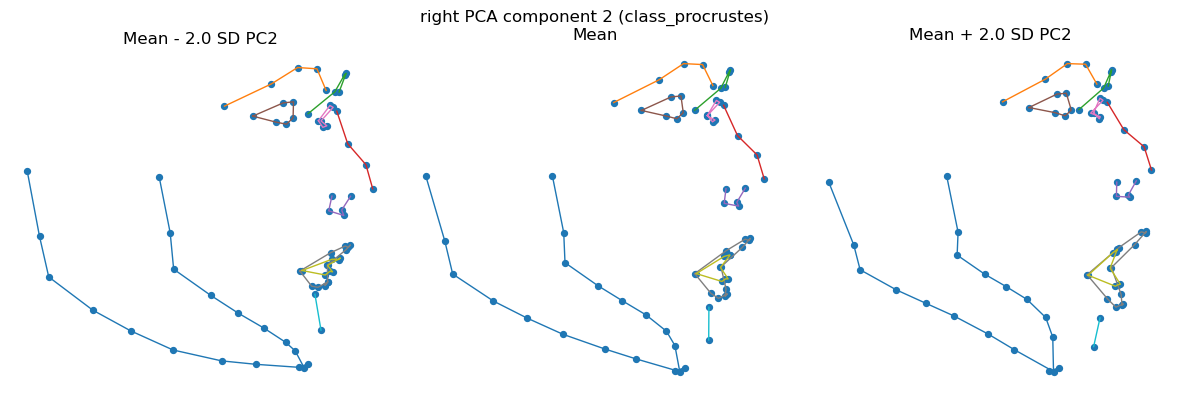

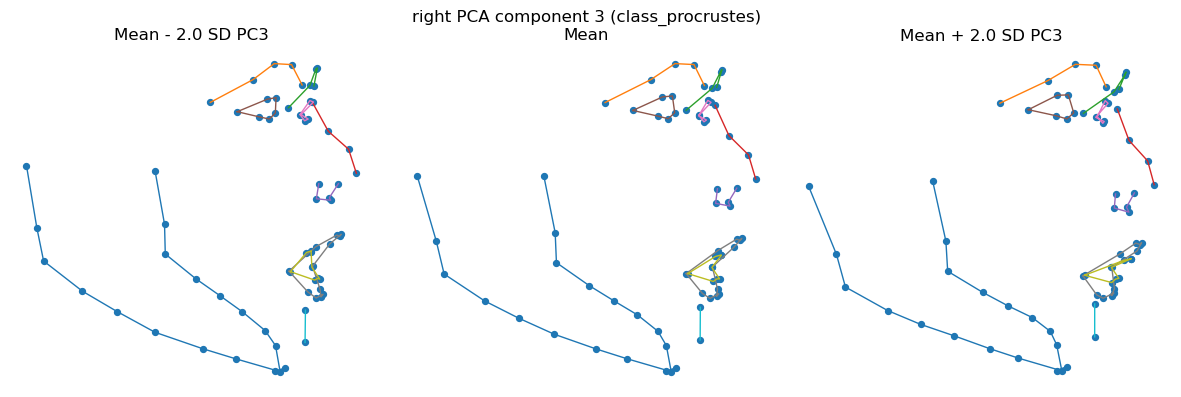

In [22]:
def plot_pca_component_variation(pca: PCAResult, pc_idx: int, output_path: Path, alpha: float = COMPONENT_STD_MULTIPLIER) -> None:
    """
    Plot mean shape and +/- PCA component variation.

    Args:
        pca: PCAResult instance.
        pc_idx: Zero-based component index.
        output_path: Path where the figure will be saved.
        alpha: Multiplier for sqrt(explained_variance).
    """
    if pc_idx >= pca.components.shape[0]:
        return
    std = math.sqrt(float(pca.explained_variance[pc_idx]))
    mean_vector = pca.mean_vector
    component = pca.components[pc_idx]
    minus_shape = unflatten_shape_vectors(mean_vector - alpha * std * component)
    mean_shape = unflatten_shape_vectors(mean_vector)
    plus_shape = unflatten_shape_vectors(mean_vector + alpha * std * component)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    plot_shape(axes[0], minus_shape, f"Mean - {alpha} SD PC{pc_idx + 1}")
    plot_shape(axes[1], mean_shape, "Mean")
    plot_shape(axes[2], plus_shape, f"Mean + {alpha} SD PC{pc_idx + 1}")
    fig.suptitle(f"{pca.scope} PCA component {pc_idx + 1} ({pca.representation})")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

for key in ["global__center_scale", "global__global_procrustes"]:
    pca = pca_results.get(key)
    if pca is None:
        continue
    for pc_idx in range(min(MAX_COMPONENTS_TO_VISUALIZE, pca.components.shape[0])):
        plot_pca_component_variation(pca, pc_idx, FIGURES_DIR / f"pca_component_{key}_pc{pc_idx + 1:02d}.png")

for representation in ["center_scale", "class_procrustes"]:
    for class_idx, class_name in CLASS_NAMES.items():
        key = f"{class_name}__{representation}"
        pca = pca_results.get(key)
        if pca is None:
            continue
        for pc_idx in range(min(3, pca.components.shape[0])):
            plot_pca_component_variation(pca, pc_idx, FIGURES_DIR / f"pca_component_{key}_pc{pc_idx + 1:02d}.png")


## PCA score distributions and normality

This section checks whether PCA component scores are approximately normal. A global PCA with multimodal PC scores usually indicates that the PCA is mixing distinct shape modes, often orientations.

In [23]:
def compute_pca_score_statistics(pcas: Dict[str, PCAResult]) -> pd.DataFrame:
    """
    Compute descriptive and normality statistics for PCA scores.

    Args:
        pcas: Dictionary of PCAResult instances.

    Returns:
        DataFrame with one row per PCA component.
    """
    rows = []
    for key, pca in pcas.items():
        for pc_idx in range(pca.scores.shape[1]):
            values = pca.scores[:, pc_idx]
            std = float(np.std(values))
            mean = float(np.mean(values))
            z_values = (values - mean) / (std + 1e-12)
            if SCIPY_AVAILABLE and len(values) >= 8:
                skewness = float(stats.skew(values, bias=False))
                excess_kurtosis = float(stats.kurtosis(values, fisher=True, bias=False))
                try:
                    shapiro_stat, shapiro_p = stats.shapiro(values) if len(values) <= 5000 else (np.nan, np.nan)
                except Exception:
                    shapiro_stat, shapiro_p = np.nan, np.nan
            else:
                centered = values - mean
                skewness = float(np.mean(centered ** 3) / ((std + 1e-12) ** 3)) if len(values) > 0 else np.nan
                excess_kurtosis = float(np.mean(centered ** 4) / ((std + 1e-12) ** 4) - 3.0) if len(values) > 0 else np.nan
                shapiro_stat, shapiro_p = np.nan, np.nan
            rows.append(
                {
                    "pca_key": key,
                    "scope": pca.scope,
                    "class_idx": pca.class_idx,
                    "class_name": pca.class_name,
                    "representation": pca.representation,
                    "pc_idx": pc_idx + 1,
                    "score_mean": mean,
                    "score_std": std,
                    "score_min": float(np.min(values)),
                    "score_max": float(np.max(values)),
                    "score_skewness": skewness,
                    "score_excess_kurtosis": excess_kurtosis,
                    "outlier_rate_abs_z_gt_3": float(np.mean(np.abs(z_values) > 3.0)),
                    "shapiro_statistic": float(shapiro_stat) if not np.isnan(shapiro_stat) else np.nan,
                    "shapiro_p_value": float(shapiro_p) if not np.isnan(shapiro_p) else np.nan,
                    "n_samples": int(len(values)),
                }
            )
    return pd.DataFrame(rows)

score_statistics = compute_pca_score_statistics(pca_results)
score_statistics.to_csv(TABLES_DIR / "pca_score_statistics.csv", index=False)
score_statistics.head(15)


,pca_key,scope,class_idx,class_name,representation,pc_idx,score_mean,score_std,score_min,score_max,score_skewness,score_excess_kurtosis,outlier_rate_abs_z_gt_3,shapiro_statistic,shapiro_p_value,n_samples
0,global__center_scale,global,NaN,None,center_scale,1,-1.856999e-15,3.763778,-5.542517,5.426291,-0.000387,-1.557057,0.000000,NaN,NaN,7974
1,global__center_scale,global,NaN,None,center_scale,2,2.147489e-15,1.586909,-2.199036,2.938862,0.023719,-1.448774,0.000000,NaN,NaN,7974
2,left__center_scale,left,0.0,left,center_scale,1,8.592403e-16,0.471223,-1.354506,1.649696,0.111192,-0.076568,0.002506,0.998665,0.260717,1596
3,left__center_scale,left,0.0,left,center_scale,2,-1.291086e-16,0.313927,-1.101045,1.013200,-0.100825,-0.057043,0.001253,0.998690,0.276627,1596
4,left__center_scale,left,0.0,left,center_scale,3,2.888249e-16,0.205971,-0.770455,0.629459,-0.101154,-0.021641,0.002506,0.998908,0.446997,1596
5,left__center_scale,left,0.0,left,center_scale,4,9.357594e-16,0.171120,-0.468554,0.549100,0.009205,-0.180230,0.000627,0.998571,0.208173,1596
6,left__center_scale,left,0.0,left,center_scale,5,-3.344582e-16,0.159064,-0.509185,0.495706,0.078234,-0.087100,0.001880,0.998951,0.486856,1596
7,left__center_scale,left,0.0,left,center_scale,6,1.562382e-16,0.151667,-0.466425,0.495203,0.099887,0.051473,0.003133,0.998470,0.162413,1596
8,left__center_scale,left,0.0,left,center_scale,7,1.163091e-16,0.139602,-0.425814,0.422242,-0.038132,-0.236742,0.002506,0.998740,0.309961,1596
9,left__center_scale,left,0.0,left,center_scale,8,1.227089e-16,0.126506,-0.414917,0.437824,0.005962,0.082346,0.004386,0.998920,0.457401,1596


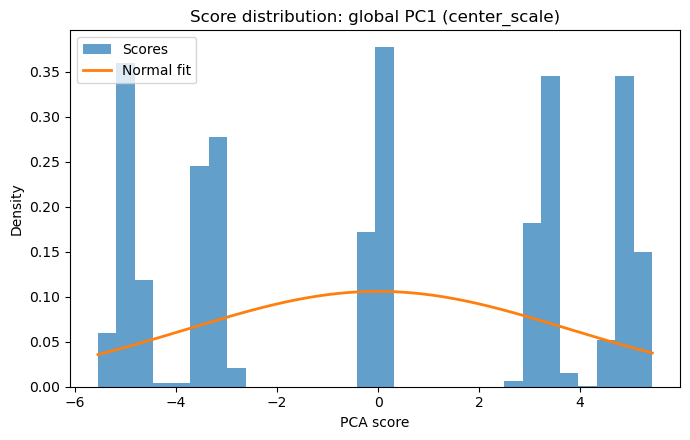

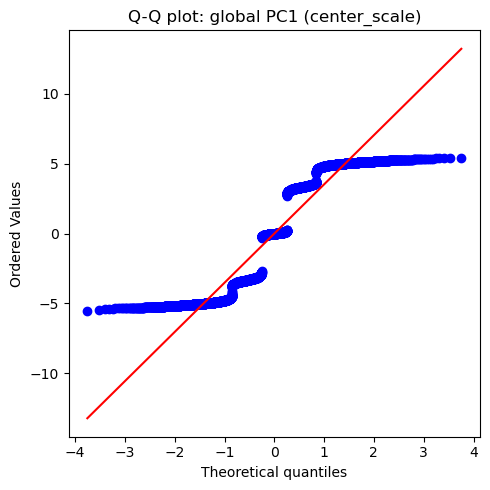

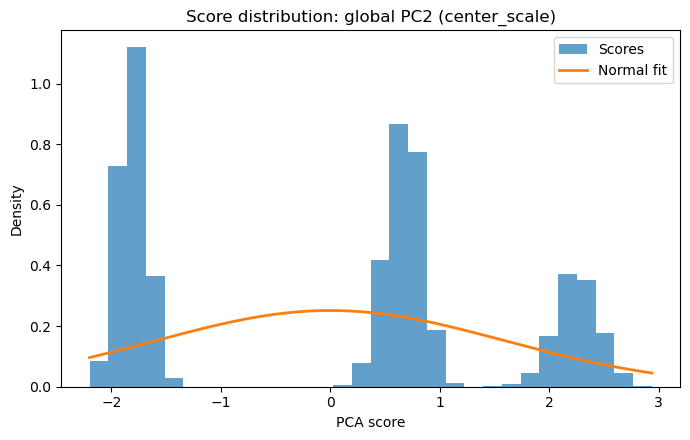

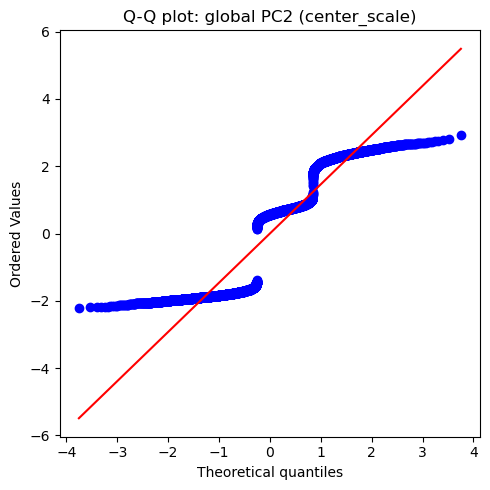

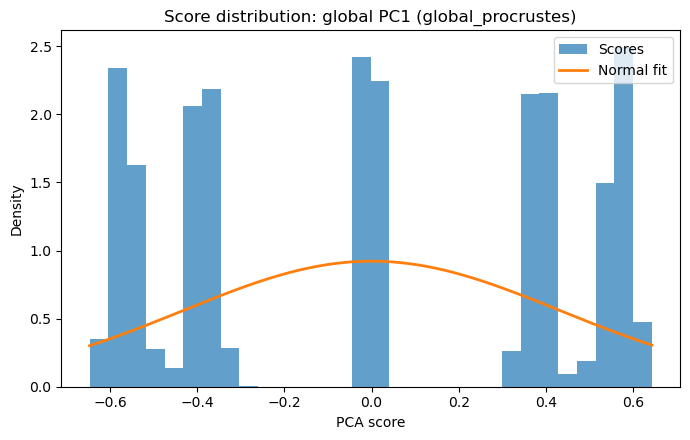

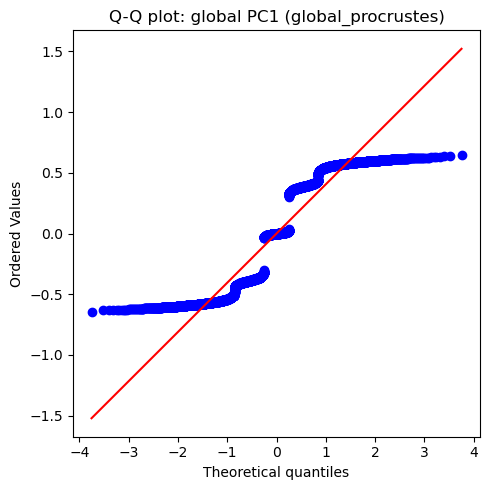

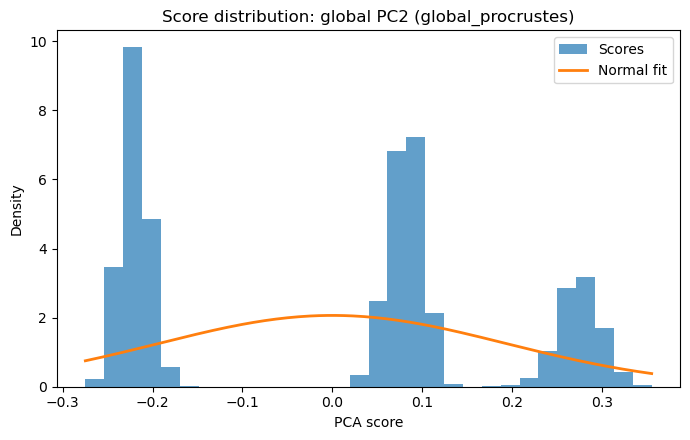

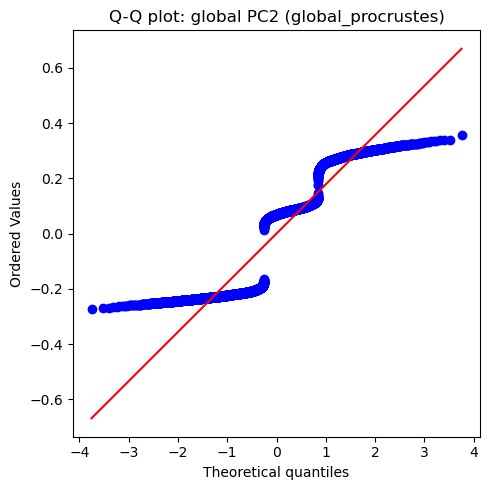

In [24]:
def plot_score_histogram(pca: PCAResult, pc_idx: int, output_path: Path) -> None:
    """
    Plot histogram of PCA scores with optional normal density overlay.

    Args:
        pca: PCAResult instance.
        pc_idx: Zero-based component index.
        output_path: Path where the figure will be saved.
    """
    if pc_idx >= pca.scores.shape[1]:
        return
    values = pca.scores[:, pc_idx]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.hist(values, bins=30, density=True, alpha=0.7, label="Scores")
    mean = float(np.mean(values))
    std = float(np.std(values))
    if std > 0:
        x_grid = np.linspace(values.min(), values.max(), 200)
        if SCIPY_AVAILABLE:
            y_grid = stats.norm.pdf(x_grid, loc=mean, scale=std)
        else:
            y_grid = (1.0 / (std * math.sqrt(2.0 * math.pi))) * np.exp(-0.5 * ((x_grid - mean) / std) ** 2)
        ax.plot(x_grid, y_grid, linewidth=2, label="Normal fit")
    ax.set_title(f"Score distribution: {pca.scope} PC{pc_idx + 1} ({pca.representation})")
    ax.set_xlabel("PCA score")
    ax.set_ylabel("Density")
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()


def plot_qq(pca: PCAResult, pc_idx: int, output_path: Path) -> None:
    """
    Plot Q-Q plot for PCA scores.

    Args:
        pca: PCAResult instance.
        pc_idx: Zero-based component index.
        output_path: Path where the figure will be saved.
    """
    if not SCIPY_AVAILABLE or pc_idx >= pca.scores.shape[1]:
        return
    values = pca.scores[:, pc_idx]
    fig, ax = plt.subplots(figsize=(5, 5))
    stats.probplot(values, dist="norm", plot=ax)
    ax.set_title(f"Q-Q plot: {pca.scope} PC{pc_idx + 1} ({pca.representation})")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

for key in ["global__center_scale", "global__global_procrustes"]:
    pca = pca_results.get(key)
    if pca is None:
        continue
    for pc_idx in range(min(5, pca.scores.shape[1])):
        plot_score_histogram(pca, pc_idx, FIGURES_DIR / f"score_hist_{key}_pc{pc_idx + 1:02d}.png")
        plot_qq(pca, pc_idx, FIGURES_DIR / f"qq_plot_{key}_pc{pc_idx + 1:02d}.png")


## Pairwise PCA score analysis

The scatter plots show whether global PCA scores cluster by orientation. If PC1 or PC2 separates class_idx groups, the global PCA is modeling pose variation rather than only within-pose anatomical variation.

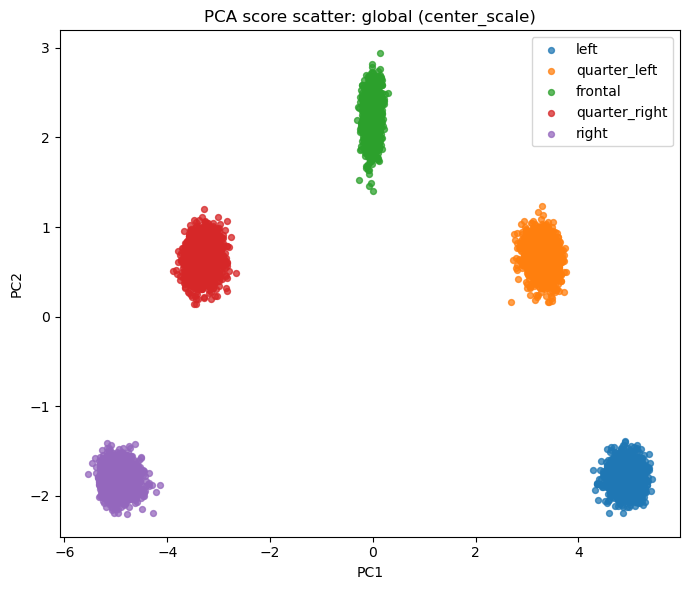

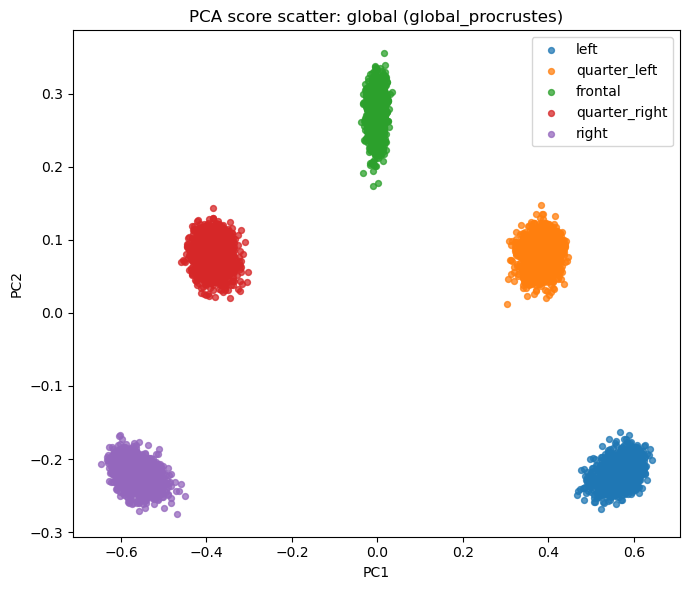

In [25]:
def plot_pca_score_scatter(pca: PCAResult, sample_class_indices: np.ndarray, output_path: Path, pc_x: int = 0, pc_y: int = 1) -> None:
    """
    Plot PCA score scatter colored by class_idx.

    Args:
        pca: PCAResult instance.
        sample_class_indices: Class indices corresponding to all samples used by the PCA.
        output_path: Path where the figure will be saved.
        pc_x: Zero-based PC index for x-axis.
        pc_y: Zero-based PC index for y-axis.
    """
    if pca.scores.shape[1] <= max(pc_x, pc_y):
        return
    classes_for_pca = sample_class_indices[pca.sample_indices]
    fig, ax = plt.subplots(figsize=(7, 6))
    for class_idx, class_name in CLASS_NAMES.items():
        mask = classes_for_pca == class_idx
        if not np.any(mask):
            continue
        ax.scatter(pca.scores[mask, pc_x], pca.scores[mask, pc_y], s=18, alpha=0.75, label=class_name)
    ax.set_title(f"PCA score scatter: {pca.scope} ({pca.representation})")
    ax.set_xlabel(f"PC{pc_x + 1}")
    ax.set_ylabel(f"PC{pc_y + 1}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

for key in ["global__center_scale", "global__global_procrustes"]:
    pca = pca_results.get(key)
    if pca is not None:
        plot_pca_score_scatter(pca, train_class_indices, FIGURES_DIR / f"score_scatter_{key}_pc1_pc2.png", pc_x=0, pc_y=1)
        plot_pca_score_scatter(pca, train_class_indices, FIGURES_DIR / f"score_scatter_{key}_pc1_pc3.png", pc_x=0, pc_y=2)


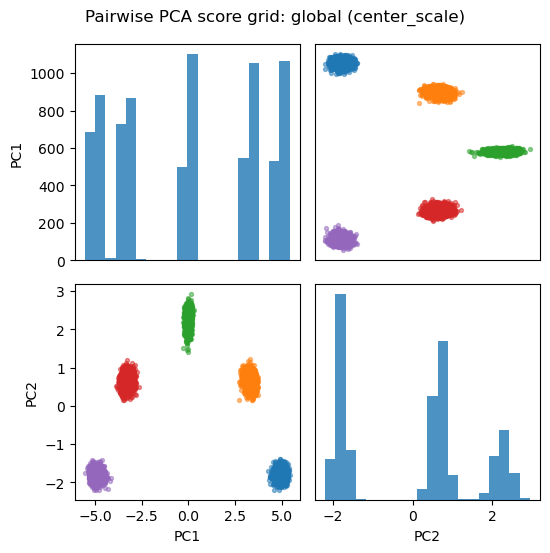

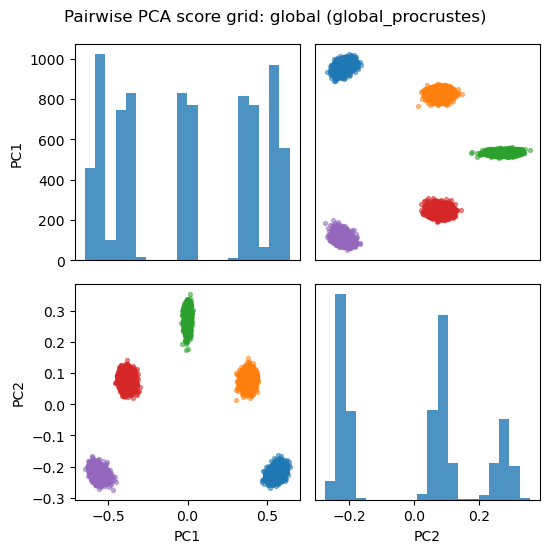

In [26]:
def plot_pairwise_score_grid(pca: PCAResult, sample_class_indices: np.ndarray, output_path: Path, num_pcs: int = 5) -> None:
    """
    Plot pairwise scatter matrix for PCA scores.

    Args:
        pca: PCAResult instance.
        sample_class_indices: Class indices for samples used by the PCA.
        output_path: Path where the figure will be saved.
        num_pcs: Number of principal components to include.
    """
    num_pcs = min(num_pcs, pca.scores.shape[1])
    if num_pcs < 2:
        return
    classes_for_pca = sample_class_indices[pca.sample_indices]
    fig, axes = plt.subplots(num_pcs, num_pcs, figsize=(2.8 * num_pcs, 2.8 * num_pcs))
    for i in range(num_pcs):
        for j in range(num_pcs):
            ax = axes[i, j]
            if i == j:
                ax.hist(pca.scores[:, i], bins=20, alpha=0.8)
            else:
                for class_idx, class_name in CLASS_NAMES.items():
                    mask = classes_for_pca == class_idx
                    if np.any(mask):
                        ax.scatter(pca.scores[mask, j], pca.scores[mask, i], s=8, alpha=0.5)
            if i == num_pcs - 1:
                ax.set_xlabel(f"PC{j + 1}")
            else:
                ax.set_xticks([])
            if j == 0:
                ax.set_ylabel(f"PC{i + 1}")
            else:
                ax.set_yticks([])
    fig.suptitle(f"Pairwise PCA score grid: {pca.scope} ({pca.representation})")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

for key in ["global__center_scale", "global__global_procrustes"]:
    pca = pca_results.get(key)
    if pca is not None:
        plot_pairwise_score_grid(pca, train_class_indices, FIGURES_DIR / f"pairwise_score_grid_{key}.png", num_pcs=5)


## Pairwise class distances

This section compares within-class and between-class distances in shape space. Large inter-class distances relative to intra-class distances indicate that orientation groups occupy distinct regions of the shape space.

In [27]:
def compute_pairwise_class_distances(vectors: np.ndarray, class_indices: np.ndarray, representation: str) -> pd.DataFrame:
    """
    Compute pairwise distances between class groups.

    Args:
        vectors: Shape vectors with shape [M, D].
        class_indices: Class index array with shape [M].
        representation: Representation name.

    Returns:
        DataFrame with pairwise class distance statistics.
    """
    rows = []
    for class_a, name_a in CLASS_NAMES.items():
        vectors_a = vectors[class_indices == class_a]
        if len(vectors_a) == 0:
            continue
        for class_b, name_b in CLASS_NAMES.items():
            vectors_b = vectors[class_indices == class_b]
            if len(vectors_b) == 0:
                continue
            if class_a == class_b and len(vectors_a) > 1:
                distance_matrix = np.sqrt(((vectors_a[:, None, :] - vectors_a[None, :, :]) ** 2).mean(axis=2))
                distances = distance_matrix[np.triu_indices_from(distance_matrix, k=1)]
            else:
                distances = np.sqrt(((vectors_a[:, None, :] - vectors_b[None, :, :]) ** 2).mean(axis=2)).reshape(-1)
            rows.append(
                {
                    "representation": representation,
                    "class_a": class_a,
                    "class_a_name": name_a,
                    "class_b": class_b,
                    "class_b_name": name_b,
                    "mean_distance": float(np.mean(distances)) if len(distances) else np.nan,
                    "median_distance": float(np.median(distances)) if len(distances) else np.nan,
                    "std_distance": float(np.std(distances)) if len(distances) else np.nan,
                    "n_distances": int(len(distances)),
                    "is_within_class": class_a == class_b,
                }
            )
    return pd.DataFrame(rows)

pairwise_distances_center = compute_pairwise_class_distances(train_vectors_center_scale, train_class_indices, "center_scale")
pairwise_distances_procrustes = compute_pairwise_class_distances(train_vectors_procrustes_by_class, train_class_indices, "class_procrustes")
pairwise_distances = pd.concat([pairwise_distances_center, pairwise_distances_procrustes], ignore_index=True)
pairwise_distances.to_csv(TABLES_DIR / "pairwise_class_distances.csv", index=False)
pairwise_distances.head()


,representation,class_a,class_a_name,class_b,class_b_name,mean_distance,median_distance,std_distance,n_distances,is_within_class
0,center_scale,0,left,0,left,0.083470,0.079238,0.025230,1272810,True
1,center_scale,0,left,1,quarter_left,0.260872,0.259815,0.018690,2550408,False
2,center_scale,0,left,2,frontal,0.538982,0.538927,0.017237,2553600,False
3,center_scale,0,left,3,quarter_right,0.722868,0.722941,0.020209,2550408,False
4,center_scale,0,left,4,right,0.829177,0.829432,0.021258,2524872,False


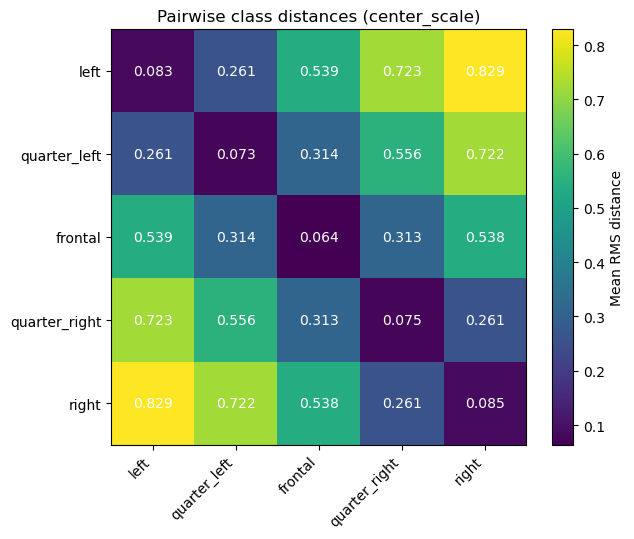

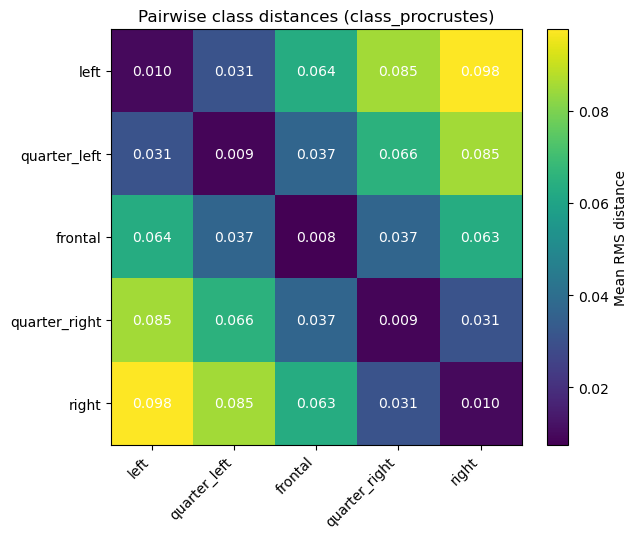

In [28]:
def plot_pairwise_distance_heatmap(distance_df: pd.DataFrame, representation: str, output_path: Path) -> None:
    """
    Plot pairwise class mean distance heatmap.

    Args:
        distance_df: DataFrame returned by compute_pairwise_class_distances.
        representation: Representation to plot.
        output_path: Path where the figure will be saved.
    """
    subset = distance_df.query("representation == @representation")
    pivot = subset.pivot(index="class_a_name", columns="class_b_name", values="mean_distance")
    order = [CLASS_NAMES[idx] for idx in sorted(CLASS_NAMES)]
    pivot = pivot.loc[order, order]
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    image = ax.imshow(pivot.values, aspect="auto")
    ax.set_xticks(np.arange(len(order)))
    ax.set_yticks(np.arange(len(order)))
    ax.set_xticklabels(order, rotation=45, ha="right")
    ax.set_yticklabels(order)
    ax.set_title(f"Pairwise class distances ({representation})")
    for i in range(len(order)):
        for j in range(len(order)):
            ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", color="white")
    fig.colorbar(image, ax=ax, label="Mean RMS distance")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

plot_pairwise_distance_heatmap(pairwise_distances, "center_scale", FIGURES_DIR / "pairwise_class_distances_center_scale.png")
plot_pairwise_distance_heatmap(pairwise_distances, "class_procrustes", FIGURES_DIR / "pairwise_class_distances_class_procrustes.png")


## Reconstruction error analysis

This section compares global PCA reconstruction error against class-conditioned PCA reconstruction error. If class-conditioned PCA reconstructs shapes better, it supports the use of a pose-conditioned prior.

In [29]:
def compute_global_vs_class_reconstruction_errors(vectors: np.ndarray, class_indices: np.ndarray, stems: Sequence[str], representation: str, pcas: Dict[str, PCAResult]) -> pd.DataFrame:
    """
    Compute global and class-conditioned PCA reconstruction errors per sample.

    Args:
        vectors: Shape vectors with shape [M, D].
        class_indices: Class index array with shape [M].
        stems: Sample stems.
        representation: Representation name.
        pcas: Dictionary of PCAResult instances.

    Returns:
        DataFrame with per-sample reconstruction errors.
    """
    global_key = f"global__{representation}"
    if global_key not in pcas:
        raise KeyError(f"Missing global PCA key: {global_key}")
    global_reconstruction = reconstruct_from_pca(pcas[global_key], vectors)
    global_errors = compute_reconstruction_error(vectors, global_reconstruction)
    rows = []
    for sample_idx, (stem, class_idx) in enumerate(zip(stems, class_indices)):
        class_name = CLASS_NAMES[int(class_idx)]
        class_key = f"{class_name}__{representation}"
        class_error = np.nan
        if class_key in pcas:
            class_reconstruction = reconstruct_from_pca(pcas[class_key], vectors[sample_idx : sample_idx + 1])
            class_error = float(compute_reconstruction_error(vectors[sample_idx : sample_idx + 1], class_reconstruction)[0])
        rows.append(
            {
                "representation": representation,
                "sample_idx": sample_idx,
                "stem": stem,
                "class_idx": int(class_idx),
                "class_name": class_name,
                "global_pca_error": float(global_errors[sample_idx]),
                "class_pca_error": class_error,
                "class_minus_global_error": class_error - float(global_errors[sample_idx]) if not np.isnan(class_error) else np.nan,
            }
        )
    return pd.DataFrame(rows)

reconstruction_center = compute_global_vs_class_reconstruction_errors(train_vectors_center_scale, train_class_indices, train_stems, "center_scale", pca_results)
reconstruction_procrustes = compute_global_vs_class_reconstruction_errors(train_vectors_procrustes_by_class, train_class_indices, train_stems, "class_procrustes", pca_results)
reconstruction_errors = pd.concat([reconstruction_center, reconstruction_procrustes], ignore_index=True)
reconstruction_errors.to_csv(TABLES_DIR / "pca_reconstruction_errors.csv", index=False)
reconstruction_errors.head()


,representation,sample_idx,stem,class_idx,class_name,global_pca_error,class_pca_error,class_minus_global_error
0,center_scale,0,synthetic_shape_00001_frontal,2,frontal,0.045276,0.009095,-0.036182
1,center_scale,1,synthetic_shape_00001_quarter_left,1,quarter_left,0.070814,0.011237,-0.059577
2,center_scale,2,synthetic_shape_00002_frontal,2,frontal,0.056001,0.009006,-0.046994
3,center_scale,3,synthetic_shape_00002_left,0,left,0.063072,0.008295,-0.054777
4,center_scale,4,synthetic_shape_00002_quarter_left,1,quarter_left,0.052791,0.008134,-0.044657


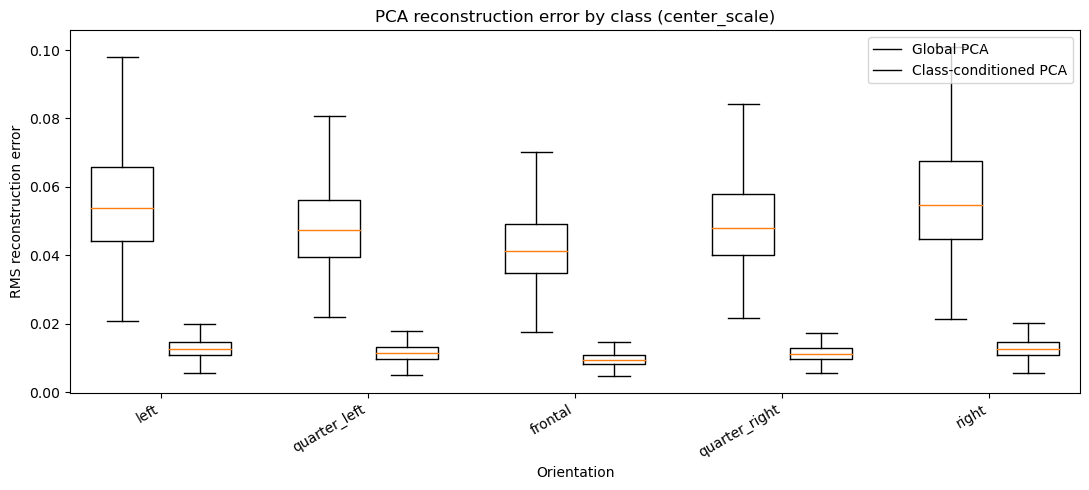

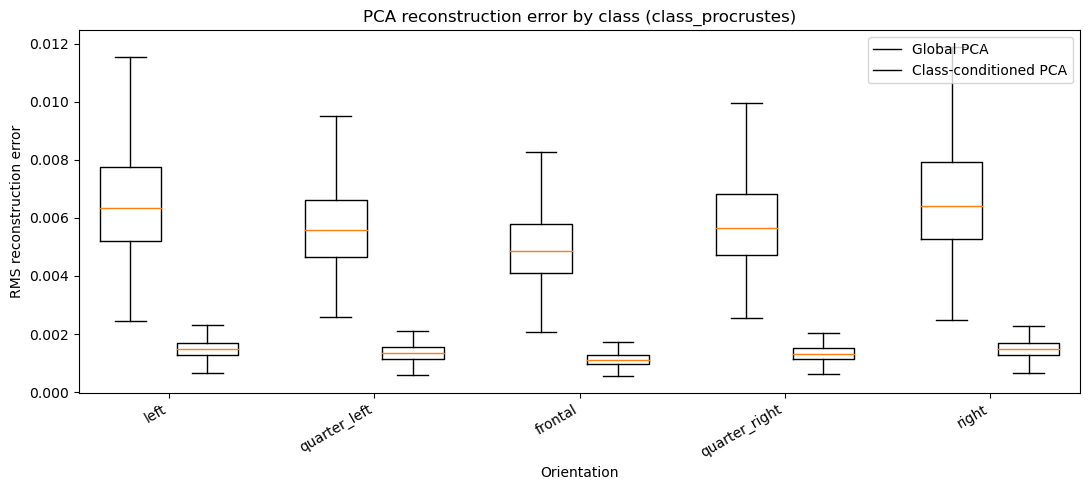

In [30]:
def plot_reconstruction_error_boxplot(reconstruction_df: pd.DataFrame, representation: str, output_path: Path) -> None:
    """
    Plot reconstruction errors by class for global and class-conditioned PCA.

    Args:
        reconstruction_df: Reconstruction error DataFrame.
        representation: Representation name.
        output_path: Path where the figure will be saved.
    """
    subset = reconstruction_df.query("representation == @representation")
    class_order = [CLASS_NAMES[idx] for idx in sorted(CLASS_NAMES)]
    global_values = [subset.loc[subset["class_name"] == class_name, "global_pca_error"].dropna().values for class_name in class_order]
    class_values = [subset.loc[subset["class_name"] == class_name, "class_pca_error"].dropna().values for class_name in class_order]
    positions_global = np.arange(len(class_order)) * 2.0
    positions_class = positions_global + 0.75
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.boxplot(global_values, positions=positions_global, widths=0.6, showfliers=False)
    ax.boxplot(class_values, positions=positions_class, widths=0.6, showfliers=False)
    ax.set_xticks(positions_global + 0.375)
    ax.set_xticklabels(class_order, rotation=30, ha="right")
    ax.set_title(f"PCA reconstruction error by class ({representation})")
    ax.set_ylabel("RMS reconstruction error")
    ax.set_xlabel("Orientation")
    ax.legend(["Global PCA", "Class-conditioned PCA"], loc="upper right")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

plot_reconstruction_error_boxplot(reconstruction_errors, "center_scale", FIGURES_DIR / "reconstruction_error_center_scale.png")
plot_reconstruction_error_boxplot(reconstruction_errors, "class_procrustes", FIGURES_DIR / "reconstruction_error_class_procrustes.png")


## Outlier inspection

The samples with the highest reconstruction error are likely to be unusual shapes, corrupted labels, extreme poses, or samples poorly represented by the selected PCA prior.

In [32]:
def save_outlier_shape_plots(reconstruction_df: pd.DataFrame, shapes: np.ndarray, samples: Sequence[LandmarkSample], representation: str, error_column: str, output_dir: Path, top_k: int = 20) -> pd.DataFrame:
    """
    Save plots for top reconstruction-error outliers.

    Args:
        reconstruction_df: DataFrame with reconstruction errors.
        shapes: Shape array with shape [M, N, 2].
        samples: LandmarkSample sequence.
        representation: Representation name.
        error_column: Error column used to rank outliers.
        output_dir: Directory where figures will be saved.
        top_k: Number of outliers to save.

    Returns:
        DataFrame with selected outliers.
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    subset = reconstruction_df.query("representation == @representation").copy()
    subset = subset.sort_values(error_column, ascending=False).head(top_k)
    for _, row in subset.iterrows():
        sample_idx = int(row["sample_idx"])
        sample = samples[sample_idx]
        shape = shapes[sample_idx]
        fig, ax = plt.subplots(figsize=(4, 4))
        plot_shape(ax, shape, f"{sample.stem}\n{sample.class_name}, {error_column}={row[error_column]:.4f}")


## Summary tables

This table quantifies whether class-conditioned PCA reduces reconstruction error relative to global PCA.

In [33]:
def summarize_reconstruction_errors(reconstruction_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize reconstruction errors by representation and class.

    Args:
        reconstruction_df: Reconstruction error DataFrame.

    Returns:
        Summary DataFrame.
    """
    grouped = reconstruction_df.groupby(["representation", "class_idx", "class_name"], dropna=False)
    summary = grouped.agg(
        mean_global_pca_error=("global_pca_error", "mean"),
        median_global_pca_error=("global_pca_error", "median"),
        mean_class_pca_error=("class_pca_error", "mean"),
        median_class_pca_error=("class_pca_error", "median"),
        n_samples=("stem", "count"),
    ).reset_index()
    summary["mean_error_reduction_class_vs_global"] = summary["mean_global_pca_error"] - summary["mean_class_pca_error"]
    summary["relative_mean_error_reduction"] = summary["mean_error_reduction_class_vs_global"] / (summary["mean_global_pca_error"] + 1e-12)
    return summary

reconstruction_summary = summarize_reconstruction_errors(reconstruction_errors)
reconstruction_summary.to_csv(TABLES_DIR / "pca_reconstruction_error_summary_by_class.csv", index=False)
reconstruction_summary


,representation,class_idx,class_name,mean_global_pca_error,median_global_pca_error,mean_class_pca_error,median_class_pca_error,n_samples,mean_error_reduction_class_vs_global,relative_mean_error_reduction
0,center_scale,0,left,0.056553,0.053752,0.012782,0.012655,1596,0.043771,0.773980
1,center_scale,1,quarter_left,0.049131,0.047372,0.011544,0.011503,1598,0.037587,0.765038
2,center_scale,2,frontal,0.042616,0.041143,0.009538,0.009390,1600,0.033078,0.776178
3,center_scale,3,quarter_right,0.050128,0.048039,0.011358,0.011199,1598,0.038770,0.773428
4,center_scale,4,right,0.057491,0.054564,0.012856,0.012709,1582,0.044635,0.776386
5,class_procrustes,0,left,0.006649,0.006334,0.001492,0.001476,1596,0.005157,0.775629
6,class_procrustes,1,quarter_left,0.005783,0.005579,0.001356,0.001351,1598,0.004426,0.765485
7,class_procrustes,2,frontal,0.005021,0.004847,0.001124,0.001106,1600,0.003897,0.776168
8,class_procrustes,3,quarter_right,0.005901,0.005649,0.001334,0.001317,1598,0.004566,0.773855
9,class_procrustes,4,right,0.006762,0.006412,0.001502,0.001486,1582,0.005260,0.777833


## Optional: save PCA candidates

This cell saves PCA candidates as `.npz` files for inspection. This is not the final training `.pt` prior format, but it lets you archive the analysis output. The training prior should later be generated by a dedicated script once you decide the final design.

In [34]:
def save_pca_results_npz(pcas: Dict[str, PCAResult], output_path: Path) -> None:
    """
    Save PCA results to a compressed NumPy archive.

    Args:
        pcas: Dictionary of PCAResult instances.
        output_path: Output .npz path.
    """
    arrays = {}
    metadata_rows = []
    for key, pca in pcas.items():
        safe_key = key.replace("/", "_")
        arrays[f"{safe_key}__mean_vector"] = pca.mean_vector
        arrays[f"{safe_key}__components"] = pca.components
        arrays[f"{safe_key}__explained_variance"] = pca.explained_variance
        arrays[f"{safe_key}__explained_variance_ratio"] = pca.explained_variance_ratio
        metadata_rows.append(
            {
                "key": key,
                "scope": pca.scope,
                "class_idx": pca.class_idx if pca.class_idx is not None else -1,
                "class_name": pca.class_name if pca.class_name is not None else "global",
                "representation": pca.representation,
                "n_samples": len(pca.sample_indices),
                "n_components": pca.components.shape[0],
            }
        )
    metadata = pd.DataFrame(metadata_rows)
    arrays["metadata_csv"] = metadata.to_csv(index=False).encode("utf-8")
    np.savez_compressed(output_path, **arrays)

save_pca_results_npz(pca_results, OUTPUT_ROOT / "pca_analysis_candidates.npz")
print(f"Saved PCA candidates to: {OUTPUT_ROOT / 'pca_analysis_candidates.npz'}")


Saved PCA candidates to: /Users/jocareher/Documents/synthetic_lmks_vis_dataset/shape_analysis_outputs/pca_analysis_candidates.npz


## Final checklist for interpretation

Use the generated outputs to answer these questions:

1. Does global PC1 mostly capture yaw?
2. Are global PCA scores multimodal by orientation?
3. Are class-conditioned PCA score distributions closer to normal?
4. Does class-conditioned PCA reduce reconstruction error compared with global PCA?
5. Which anatomical groups have the highest variability?
6. Which samples are reconstruction outliers?
7. Does Procrustes reduce nuisance variation or does it hide real yaw variation?
8. Which PCA design is most defensible for the next experiment?

Recommended files to inspect first:

```text
figures/score_scatter_global__center_scale_pc1_pc2.png
figures/pca_component_global__center_scale_pc01.png
figures/reconstruction_error_center_scale.png
tables/pca_score_statistics.csv
tables/pca_reconstruction_error_summary_by_class.csv
tables/landmark_variability.csv
```